# ASSIGNMENT 06: RECURRENT NEURAL NETWORKS (RNN)
## Notebook 01: Dự Đoán Giá Cổ Phiếu S&P 500 Bằng PyTorch Vanilla RNN
### Tích hợp Toàn diện: Tiền Xử Lý Chuỗi Thời Gian, Xây Dựng Mô Hình, Huấn Luyện, Đánh Giá & Phân Tích Tài Chính

---

### Mục tiêu tổng thể của Notebook:
Notebook này cung cấp một quy trình hoàn chỉnh (End-to-End Deep Learning Pipeline) chuẩn mực khoa học nhằm giải quyết bài toán dự báo chuỗi thời gian tài chính sử dụng mạng hồi quy **Vanilla RNN** xây dựng từ đầu bằng **PyTorch**:

* **PHẦN 1: Chuẩn bị Dữ liệu & Tiền xử lý Chuỗi Thời Gian**:
  1. Kiểm tra nguồn dữ liệu thực tế S&P 500 (`all_stocks_5yr.csv`).
  2. Tổng quan cấu trúc dữ liệu, kiểm tra tính toàn vẹn (Missing values, duplicates).
  3. Khám phá & Trực quan hóa dữ liệu (EDA): Phân bố giá đóng cửa, xu hướng biến động (Trend/SMA), thanh khoản volume và so sánh đa mã cổ phiếu.
  4. Thiết kế bài toán chuỗi thời gian: Lựa chọn mã tiêu biểu (`AAPL`), Target (`close` tại $t+1$), Features (OHLCV).
  5. Phân chia dữ liệu theo trục thời gian (Time-based Split: 70% Train, 15% Val, 15% Test) chống rò rỉ dữ liệu (Data Leakage).
  6. Chuẩn hóa dữ liệu bằng `MinMaxScaler`, fit nghiêm ngặt chỉ trên tập Train.
  7. Tạo cấu trúc cửa sổ trượt (Sliding Window $L=20$).
  8. Đóng gói PyTorch Dataset & DataLoader (`shuffle=False`).

* **PHẦN 2: Xây Dựng, Huấn Luyện & Đánh Giá Mô Hình PyTorch RNN**:

  9. Thiết lập tính tái lập (Reproducibility: Random Seed) và thông tin phần cứng (CPU/GPU, PyTorch Version).
  10. Xây dựng kiến trúc mô hình tối giản: `Input -> torch.nn.RNN -> Linear -> Prediction`.
  11. Thiết lập hàm mất mát (`nn.MSELoss`) và thuật toán tối ưu (`optim.Adam`).
  12. Xây dựng Training Loop hoàn chỉnh kèm cơ chế Validation qua từng Epoch.
  13. Theo dõi, vẽ biểu đồ Loss và phân tích hiện tượng Overfitting.
  14. Thực hiện dự đoán trên Test Set và khôi phục thang đo gốc bằng `inverse_transform`.
  15. Đánh giá đa chiều với bộ chỉ số định lượng: MAE, MSE, RMSE, MAPE, $R^2$.
  16. Trực quan hóa so sánh Thực tế vs Dự đoán (Actual vs Predicted) và biểu đồ phần dư (Residuals).
  17. Phân tích chuyên sâu: Năng lực dự báo xu hướng, các giai đoạn sai lệch lớn, ảnh hưởng của lookback window, hiện tượng trễ pha (phase lag) và bản chất khó lường của thị trường tài chính (EMH, SNR thấp).
  18. Tổng kết toàn diện (`Conclusion`).

---

### Bảng Mục Lục Điều Hướng:
#### PHẦN 1: EDA, TIỀN XỬ LÝ & CHUẨN BỊ DỮ LIỆU
1. [Xác định & Tải file Dataset](#section-1)
2. [Dataset Overview (Tổng quan về tập dữ liệu)](#section-2)
3. [Phân tích phân bố dữ liệu (EDA) & Ý nghĩa thực tiễn](#section-3)
4. [Liên hệ với bài toán RNN & Lựa chọn Target / Feature](#section-4)
5. [Thiết kế bài toán dự đoán (Sliding Window Formulation)](#section-5)
6. [Phân chia Train / Validation / Test theo trục thời gian](#section-6)
7. [Chuẩn hóa dữ liệu (Scaling) & Phòng chống Data Leakage](#section-7)
8. [Tạo cấu trúc Sliding Window (X, y)](#section-8)
9. [Xây dựng PyTorch Dataset & DataLoader](#section-9)
10. [Ready for PyTorch RNN (Bảng tổng kết chuẩn bị)](#section-10)

#### PHẦN 2: XÂY DỰNG, HUẤN LUYỆN & ĐÁNH GIÁ MÔ HÌNH PYTORCH RNN
11. [Reproducibility & Thiết Lập Môi Trường (Random Seed, Device, Version)](#section-11)
12. [Xây Dựng RNN Model Với PyTorch (`torch.nn.RNN`)](#section-12)
13. [Lựa Chọn Hàm Mất Mát (Loss) & Thuật Toán Tối Ưu (Optimizer)](#section-13)
14. [Quy Trình Huấn Luyện (Training Loop) Hoàn Chỉnh](#section-14)
15. [Theo Dõi Quá Trình Huấn Luyện & Phân Tích Loss (Overfitting Analysis)](#section-15)
16. [Dự Đoán Trên Test Set & Khôi Phục Thang Đo Gốc (Inverse Transform)](#section-16)
17. [Đánh Giá Hiệu Năng Mô Hình (Evaluation Metrics: MAE, MSE, RMSE, MAPE, R2)](#section-17)
18. [Trực Quan Hóa Kết Quả Dự Đoán (Actual vs Predicted & Residuals)](#section-18)
19. [Phân Tích Chuyên Sâu Kết Quả & Giới Hạn Của RNN Trong Tài Chính](#section-19)
20. [Conclusion (Tổng Kết Cuối Cùng)](#section-20)


---
<a id="section-1"></a>
## 1. Xác định & Tải file Dataset

### 1.1. Kiểm tra môi trường & Đường dẫn Dataset thực tế:
Bộ dữ liệu được cung cấp trong thư mục dự án `Assignment 06/dataset/`:
* **Tên file dataset**: `all_stocks_5yr.csv`
* **Đường dẫn tương đối**: `dataset/all_stocks_5yr.csv`
* **Nguồn dữ liệu**: Kaggle - *S&P 500 Stock Data* (tác giả Cam Nugent). [Link Kaggle Dataset](https://www.kaggle.com/datasets/camnugent/sandp500)
* Dữ liệu ghi nhận thông tin giao dịch lịch sử 5 năm của các công ty trong chỉ số chứng khoán S&P 500.

Đoạn code bên dưới sẽ kiểm tra sự tồn tại của file và tải dữ liệu vào DataFrame.


In [1]:
# 1. Kiểm tra đường dẫn và đọc dataset
import os
import pandas as pd
import numpy as np

from pathlib import Path
dataset_candidates = [Path("dataset/all_stocks_5yr.csv"), Path("Assignment 06/dataset/all_stocks_5yr.csv"), Path("../dataset/all_stocks_5yr.csv")]
dataset_path = next((p for p in dataset_candidates if p.is_file()), dataset_candidates[0])

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại đường dẫn: {dataset_path}")

print(f"-> Đã xác thực file dataset tồn tại tại: {dataset_path}")
print(f"-> Dung lượng file: {os.path.getsize(dataset_path) / (1024 * 1024):.2f} MB")

# Đọc dữ liệu vào Pandas DataFrame
df_raw = pd.read_csv(dataset_path)
print(f"-> Đọc dữ liệu thành công! Kích thước ban đầu: {df_raw.shape[0]:,} dòng, {df_raw.shape[1]} cột.")


-> Đã xác thực file dataset tồn tại tại: dataset\all_stocks_5yr.csv
-> Dung lượng file: 28.21 MB


-> Đọc dữ liệu thành công! Kích thước ban đầu: 619,040 dòng, 7 cột.


---
<a id="section-2"></a>
## 2. Dataset Overview (Tổng Quan Về Tập Dữ Liệu)

### 2.1. Cấu trúc tổng thể của Dataset:
* **Nguồn gốc**: File S&P 500 Stock Data từ Kaggle chứa 505 mã cổ phiếu trong phạm vi dataset; không phải bảng xếp hạng 505 công ty lớn nhất.
* **Số dòng**: 619,040 dòng.
* **Số cột**: 7 cột.
* **Ý nghĩa chi tiết của 7 cột**:
  1. `date`: Ngày giao dịch (định dạng YYYY-MM-DD).
  2. `open`: Giá mở cửa của phiên giao dịch (USD).
  3. `high`: Mức giá cao nhất đạt được trong phiên (USD).
  4. `low`: Mức giá thấp nhất chạm tới trong phiên (USD).
  5. `close`: Mức giá đóng cửa chốt phiên (USD) — *Đặc trưng quan trọng nhất*.
  6. `volume`: Tổng khối lượng cổ phiếu được khớp lệnh trong ngày.
  7. `Name`: Mã niêm yết (Ticker Symbol) của công ty (ví dụ: `AAPL`, `GOOGL`, `MSFT`, `AMZN`).

### 2.2. Kiểm tra chất lượng dữ liệu:
* **Khoảng thời gian**: Từ ngày **`2013-02-08`** đến ngày **`2018-02-07`** (tròn 5 năm, tương ứng 1,259 ngày giao dịch).
* **Số lượng mã cổ phiếu**: 505 mã công ty khác nhau.
* **Missing values**: Toàn bộ dataset chỉ có 11 giá trị rỗng ở cột `open`, 8 ở `high`, 8 ở `low`. Cột `close` và `volume` có **0 missing values**!
* **Duplicates**: **0 dòng trùng lặp**.
* **Nhận định về tính dị biệt (Abnormalities)**:
  * Vì dataset chứa 505 công ty từ nhiều ngành nghề khác nhau (từ cổ phiếu công nghệ hàng nghìn USD đến cổ phiếu tài chính vài USD), giá trị trung bình toàn bộ bảng không phản ánh một chuỗi thời gian liên tục duy nhất.
  * Không nối cửa sổ qua ranh giới hai mã. Bài chọn một mã AAPL để thực nghiệm; mô hình nhiều mã vẫn có thể xây dựng nếu tạo chuỗi riêng theo từng mã.
  * Chúng ta lựa chọn mã cổ phiếu tiêu biểu nhất thị trường công nghệ toàn cầu: **Apple Inc. (`AAPL`)**.


In [2]:
# In thông tin tổng quan của dataset bằng code
print("=== 1. NĂM DÒNG ĐẦU TIÊN CỦA DATASET ===")
display(df_raw.head())

print("\n=== 2. THÔNG TIN KIỂU DỮ LIỆU & BỘ NHỚ ===")
df_raw.info()

print("\n=== 3. THỐNG KÊ GIÁ TRỊ THIẾU (MISSING VALUES) ===")
missing_summary = df_raw.isnull().sum()
missing_percent = (missing_summary / len(df_raw)) * 100
df_missing = pd.DataFrame({'Missing Count': missing_summary, 'Percentage (%)': missing_percent})
display(df_missing)

print("\n=== 4. SỐ DÒNG TRÙNG LẶP (DUPLICATES) ===")
print("Số dòng trùng lặp hoàn toàn:", df_raw.duplicated().sum())

print("\n=== 5. KHOẢNG THỜI GIAN & SỐ LƯỢNG MÃ CỔ PHIẾU ===")
print(f"Ngày bắt đầu : {df_raw['date'].min()}")
print(f"Ngày kết thúc: {df_raw['date'].max()}")
print(f"Tổng số mã cổ phiếu duy nhất: {df_raw['Name'].nunique()} mã")

print("\n=== 6. TOP 10 MÃ CỔ PHIẾU CÓ NHIỀU QUAN SÁT NHẤT ===")
print(df_raw['Name'].value_counts().head(10))


=== 1. NĂM DÒNG ĐẦU TIÊN CỦA DATASET ===


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL



=== 2. THÔNG TIN KIỂU DỮ LIỆU & BỘ NHỚ ===
<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 40.8 MB

=== 3. THỐNG KÊ GIÁ TRỊ THIẾU (MISSING VALUES) ===


,Missing Count,Percentage (%)
date,0,0.000000
open,11,0.001777
high,8,0.001292
low,8,0.001292
close,0,0.000000
volume,0,0.000000
Name,0,0.000000



=== 4. SỐ DÒNG TRÙNG LẶP (DUPLICATES) ===


Số dòng trùng lặp hoàn toàn: 0

=== 5. KHOẢNG THỜI GIAN & SỐ LƯỢNG MÃ CỔ PHIẾU ===
Ngày bắt đầu : 2013-02-08
Ngày kết thúc: 2018-02-07
Tổng số mã cổ phiếu duy nhất: 505 mã

=== 6. TOP 10 MÃ CỔ PHIẾU CÓ NHIỀU QUAN SÁT NHẤT ===
Name
AAL     1259
AAPL    1259
AAP     1259
ABBV    1259
ABC     1259
ABT     1259
ACN     1259
ADBE    1259
ADI     1259
ADM     1259
Name: count, dtype: int64


---
<a id="section-3"></a>
## 3. Phân Tích Phân Bố Dữ Liệu (EDA) & Ý Nghĩa Thực Tiễn

Để xây dựng một mô hình dự báo chuỗi thời gian chính xác, việc quan sát các đặc trưng thống kê và trực quan hóa dữ liệu là tối quan trọng. Chúng ta sẽ trích xuất chuỗi dữ liệu của **Apple Inc. (`AAPL`)** — một trong những mã cổ phiếu có có dữ liệu OHLCV đầy đủ, đầy đủ 1,259 phiên giao dịch không có bất kỳ giá trị thiếu nào.

Chúng ta sẽ tiến hành 4 phân tích trực quan chuyên sâu:
1. **Phân bố của giá trị đóng cửa (`close`)**: Đánh giá độ lệch chuẩn và hình dạng phân bố.
2. **Biến động giá theo thời gian**: Nhận diện xu hướng (Trend) và chu kỳ.
3. **Khối lượng giao dịch (`volume`) theo thời gian**: Nhận diện thanh khoản và các điểm bùng nổ thông tin.
4. **So sánh sự khác nhau giữa các mã cổ phiếu tiêu biểu**: Khẳng định sự cần thiết của việc tách riêng từng mã để mô hình hóa.


In [3]:
# Trích xuất và tiền xử lý thời gian cho cổ phiếu AAPL
df_aapl = df_raw[df_raw['Name'] == 'AAPL'].copy()

# Chuyển đổi cột date sang kiểu datetime chuẩn và sắp xếp theo thứ tự thời gian tăng dần
df_aapl['date'] = pd.to_datetime(df_aapl['date'])
df_aapl = df_aapl.sort_values('date').reset_index(drop=True)

print(f"Số lượng quan sát của AAPL: {len(df_aapl)} ngày giao dịch liên tục.")
print(f"Khung thời gian từ: {df_aapl['date'].min().strftime('%d/%m/%Y')} đến {df_aapl['date'].max().strftime('%d/%m/%Y')}")
print("Kiểm tra missing values trong tập AAPL:\n", df_aapl.isnull().sum())
display(df_aapl.head(3))


Số lượng quan sát của AAPL: 1259 ngày giao dịch liên tục.
Khung thời gian từ: 08/02/2013 đến 07/02/2018
Kiểm tra missing values trong tập AAPL:
 date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64


,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL


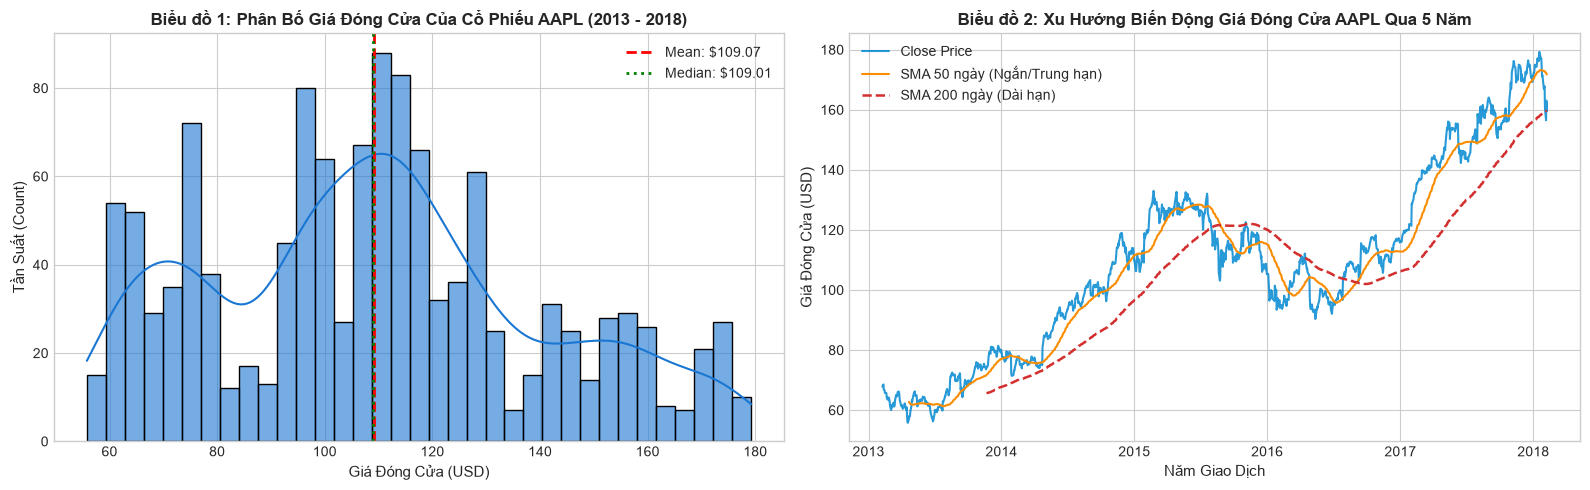

In [4]:
# Trực quan hóa Biểu đồ 1 & Biểu đồ 2: Phân bố giá và Xu hướng biến động theo thời gian
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- BIỂU ĐỒ 1: PHÂN BỐ GIÁ ĐÓNG CỬA (CLOSE PRICE DISTRIBUTION) ---
sns.histplot(df_aapl['close'], kde=True, ax=axes[0], color='#1976D2', bins=35, edgecolor='black', alpha=0.6)
axes[0].axvline(df_aapl['close'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: ${df_aapl['close'].mean():.2f}")
axes[0].axvline(df_aapl['close'].median(), color='green', linestyle=':', linewidth=2, label=f"Median: ${df_aapl['close'].median():.2f}")
axes[0].set_title("Biểu đồ 1: Phân Bố Giá Đóng Cửa Của Cổ Phiếu AAPL (2013 - 2018)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Giá Đóng Cửa (USD)", fontsize=11)
axes[0].set_ylabel("Tần Suất (Count)", fontsize=11)
axes[0].legend(fontsize=10)

# --- BIỂU ĐỒ 2: BIẾN ĐỘNG THEO THỜI GIAN VÀ ĐƯỜNG TRUNG BÌNH ĐỘNG (SMA) ---
df_aapl['SMA_50'] = df_aapl['close'].rolling(window=50).mean()
df_aapl['SMA_200'] = df_aapl['close'].rolling(window=200).mean()

axes[1].plot(df_aapl['date'], df_aapl['close'], label='Close Price', color='#0288D1', linewidth=1.5, alpha=0.85)
axes[1].plot(df_aapl['date'], df_aapl['SMA_50'], label='SMA 50 ngày (Ngắn/Trung hạn)', color='#FB8C00', linewidth=1.5)
axes[1].plot(df_aapl['date'], df_aapl['SMA_200'], label='SMA 200 ngày (Dài hạn)', color='#D32F2F', linewidth=1.8, linestyle='--')
axes[1].set_title("Biểu đồ 2: Xu Hướng Biến Động Giá Đóng Cửa AAPL Qua 5 Năm", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Năm Giao Dịch", fontsize=11)
axes[1].set_ylabel("Giá Đóng Cửa (USD)", fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


### Dữ liệu này phân bố như vậy có ý nghĩa gì?

#### 1. Ý nghĩa của Biểu đồ 1 (Phân bố giá đóng cửa):
* **Hình dạng phân bố**: Phân bố giá đóng cửa của AAPL **không tuân theo phân bố chuẩn Gauss (Non-normal distribution)**. Đồ thị có dạng hai đỉnh (bimodal) và trải dài từ $55.79$ USD lên đến $179.26$ USD.
* **Ý nghĩa đối với bài toán học máy**: 
  * Giá trị trung bình (Mean $\approx 109.07$ USD) và trung vị (Median $\approx 109.01$ USD) nằm ở vùng giữa, nhưng mật độ tập trung dày đặc ở hai khoảng giá: $70 - 90$ USD (giai đoạn 2013–2014) và $110 - 130$ USD (giai đoạn 2015–2016).
  * Biểu đồ theo thời gian gợi ý mức giá thay đổi giữa các giai đoạn. Histogram đa đỉnh đơn thuần chưa chứng minh chuỗi phi dừng; bài chưa thực hiện kiểm định tính dừng.
  * Bài dùng chuẩn hóa từng đặc trưng để giảm chênh lệch thang đo và hỗ trợ tối ưu; đây không phải điều kiện bắt buộc về mặt toán học.

#### 2. Ý nghĩa của Biểu đồ 2 (Xu hướng biến động theo thời gian):
* **Xu hướng dài hạn**: Giá cao nhất / thấp nhất xấp xỉ 3.21 lần, tức chênh lệch khoảng 221%, không phải tăng hơn 300%. Giá đầu đến cuối giai đoạn tăng khoảng 135.12%; hai cách so sánh không đồng nhất.
* **Các nhịp điều chỉnh chu kỳ**: Năm 2015–2016 có một đợt suy giảm điều chỉnh lớn khi giá cắt xuống dưới đường SMA 200 ngày, sau đó phục hồi mạnh mẽ từ cuối 2016.
* **Ý nghĩa với RNN**: 
  * Giá ngày hôm nay ($t$) có **mối tương quan tự thân cực kỳ mạnh mẽ (Autocorrelation)** với các ngày trước đó ($t-1, t-2, \dots$). 
  * SMA mô tả giá quá khứ được làm mịn, chưa chứng minh momentum tiếp tục hoặc RNN là mô hình tối ưu. Cần đối chiếu dự báo trên Test với baseline.


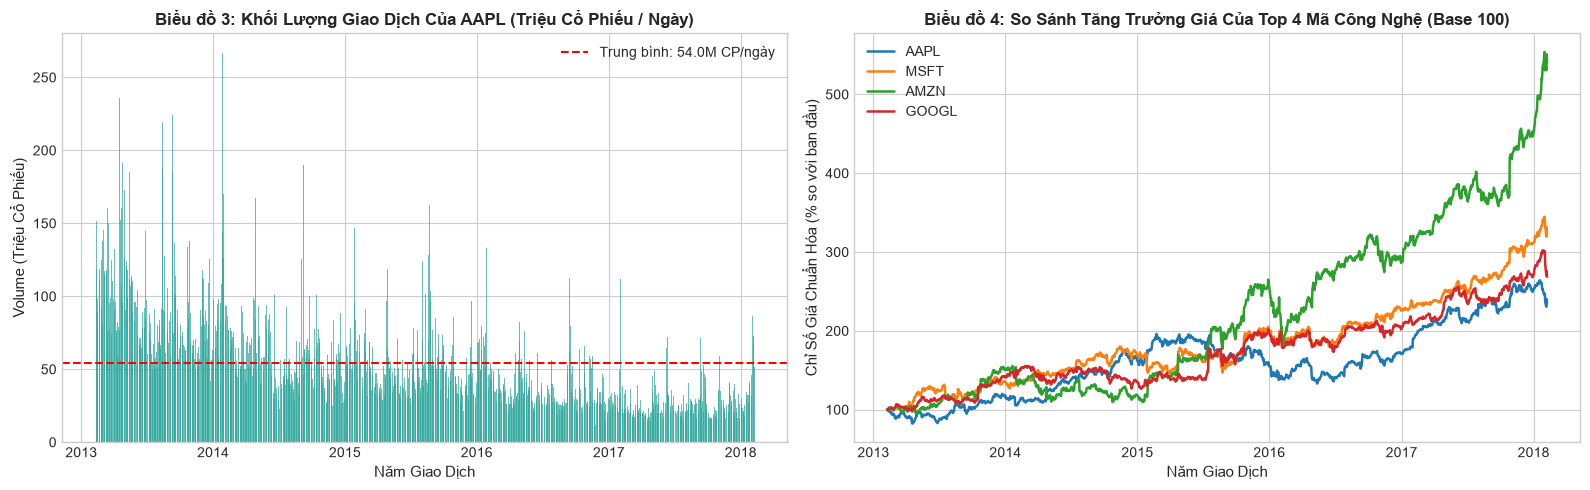

In [5]:
# Trực quan hóa Biểu đồ 3: Khối lượng giao dịch & Biểu đồ 4: So sánh đa mã cổ phiếu
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- BIỂU ĐỒ 3: KHỐI LƯỢNG GIAO DỊCH (VOLUME) THEO THỜI GIAN ---
axes[0].bar(df_aapl['date'], df_aapl['volume'] / 1e6, color='#26A69A', width=2, alpha=0.7)
axes[0].set_title("Biểu đồ 3: Khối Lượng Giao Dịch Của AAPL (Triệu Cổ Phiếu / Ngày)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Năm Giao Dịch", fontsize=11)
axes[0].set_ylabel("Volume (Triệu Cổ Phiếu)", fontsize=11)

# Đánh dấu mức trung bình
mean_vol = df_aapl['volume'].mean() / 1e6
axes[0].axhline(mean_vol, color='red', linestyle='--', linewidth=1.5, label=f"Trung bình: {mean_vol:.1f}M CP/ngày")
axes[0].legend(fontsize=10)

# --- BIỂU ĐỒ 4: SO SÁNH BIẾN ĐỘNG GIÁ GIỮA CÁC MÃ CỔ PHIẾU CÔNG NGHỆ HÀNG ĐẦU ---
top_tech = ['AAPL', 'MSFT', 'AMZN', 'GOOGL']
df_tech = df_raw[df_raw['Name'].isin(top_tech)].copy()
df_tech['date'] = pd.to_datetime(df_tech['date'])

# Chuẩn hóa về phần trăm tăng trưởng từ điểm mốc đầu tiên (Base 100) để so sánh khách quan
pivoted = df_tech.pivot(index='date', columns='Name', values='close').dropna()
normalized_growth = (pivoted / pivoted.iloc[0]) * 100

for ticker in top_tech:
    axes[1].plot(normalized_growth.index, normalized_growth[ticker], label=ticker, linewidth=1.8)

axes[1].set_title("Biểu đồ 4: So Sánh Tăng Trưởng Giá Của Top 4 Mã Công Nghệ (Base 100)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Năm Giao Dịch", fontsize=11)
axes[1].set_ylabel("Chỉ Số Giá Chuẩn Hóa (% so với ban đầu)", fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


### Dữ liệu này phân bố như vậy có ý nghĩa gì?

#### 1. Ý nghĩa của Biểu đồ 3 (Khối lượng giao dịch - Volume):
* **Tính chất đột biến (Volume Spikes)**: Khối lượng giao dịch trung bình của AAPL đạt khoảng $54$ triệu cổ phiếu/ngày, nhưng xuất hiện nhiều phiên bùng nổ lên tới hơn $200$ triệu cổ phiếu (gấp 4 lần bình thường).
* **Giới hạn diễn giải**: OHLCV không có thông tin sự kiện, nên chưa xác định nguyên nhân của các đỉnh volume.
* **Hàm ý tiền xử lý**: 
  * Cột `volume` có độ lớn ở thang đo hàng chục triệu ($10^7$), trong khi giá `close` chỉ ở thang đo hàng trăm ($10^2$). 
  * Chênh lệch thang đo có thể làm khó tối ưu và gây bão hòa kích hoạt. Chuẩn hóa hỗ trợ cân bằng đầu vào nhưng không bảo đảm gradient ổn định.

#### 2. Ý nghĩa của Biểu đồ 4 (So sánh giữa các mã cổ phiếu):
* **So sánh Base 100**: Cuối giai đoạn, AMZN = 540.86, MSFT = 325.26, AAPL = 235.12, GOOGL = 268.50. Tỷ lệ tăng tương ứng là **440.86%, 225.26%, 135.12%, 168.50%** so với điểm đầu.
* **Quyết định thiết kế bài toán**: 
  * Mỗi công ty có biên độ dao động, chu kỳ dòng tiền và mức độ thanh khoản riêng.
  * Việc huấn luyện một mạng RNN duy nhất trên một chuỗi thời gian đồng nhất của từng mã cổ phiếu cụ thể (ở đây là `AAPL`) là phương pháp khoa học, hạn chế tối đa nhiễu chéo (cross-ticker noise) và đảm bảo tính liên tục của hàm tự tương quan thời gian.

> **Base 100**: Chỉ số 250 nghĩa là giá bằng 2.5 lần ban đầu, tức tăng 150%, không phải tăng 250%. Biểu đồ không xác định nguyên nhân kinh doanh của mức tăng.


---
<a id="section-4"></a>
## 4. Liên Hệ Với Bài Toán RNN & Lựa Chọn Target / Feature

### 4.1. Tại sao dữ liệu chứng khoán là Sequential / Time-Series Data?
* **Tính trật tự nghiêm ngặt (Strict Chronological Order)**: Một mức giá $150$ USD xuất hiện sau chuỗi 5 ngày tăng liên tiếp mang tâm lý thị trường hưng phấn hoàn toàn khác với mức giá $150$ USD xuất hiện sau một phiên bán tháo sập sàn. Nếu xáo trộn thứ tự các ngày, mọi chỉ báo xu hướng đều bị xóa bỏ.
* **Tính phụ thuộc quá khứ (Temporal Dependency)**: Xu hướng biến động ngày mai được định hình bởi dòng tiền, lực mua/bán và quán tính tích lũy từ các phiên giao dịch trước đó.

### 4.2. Tại sao RNN phù hợp về mặt bản chất bài toán?
1. **Duy trì bộ nhớ ngữ cảnh qua trạng thái ẩn ($h_t$)**: RNN truyền tải vector $h_{t-1}$ sang bước $t$, giúp mạng "ghi nhớ" được chuỗi diễn biến giá của cả tuần hoặc cả tháng trước đó để đưa ra dự báo.
2. **Chia sẻ trọng số (Weight Sharing)**: Cùng một cơ chế học được áp dụng lặp lại qua mọi ngày, giúp mô hình nhận diện các mẫu hình giá lặp lại (mô hình đảo chiều, tích lũy) bất kể chúng xuất hiện vào năm 2014 hay năm 2017.

---

### 4.3. Quyết định lựa chọn Biến mục tiêu (Target) & Các đặc trưng (Features):

#### A. Lựa chọn Biến mục tiêu (Target Variable):
* **Target được chọn**: **Giá đóng cửa của ngày tiếp theo (`close` tại thời điểm $t+1$)**.
* **Giải thích lý do**: 
  * Giá đóng cửa là một đại lượng liên tục có sẵn trong dataset, thuận tiện để minh họa bài toán dự báo phiên kế tiếp.
  * Chỉ dự báo sau khi OHLCV phiên hiện tại đã được quan sát đầy đủ. Bài chưa mô phỏng đặt lệnh nên không khẳng định có thể giao dịch ngay tại giá đóng cửa vừa quan sát.

#### B. Lựa chọn Các đặc trưng đầu vào (Input Features):
Ta sử dụng **bài toán Đa biến (Multivariate Forecasting)** với **5 đặc trưng cốt lõi**:
$$\text{Features} = [\text{open}, \text{high}, \text{low}, \text{close}, \text{volume}]$$
* `open`, `high`, `low`, `close` (OHLC): Cung cấp bức tranh toàn cảnh về biên độ dao động, tâm lý giằng co giữa phe bò (mua) và phe gấu (bán) trong phiên.
* `volume`: Khối lượng giao dịch của các phiên trước; có thể cung cấp thông tin bổ sung, nhưng chưa kiểm chứng lợi ích dự báo hoặc tín hiệu bull-trap chỉ từ đặc trưng này.
* Số lượng đặc trưng: **`input_size = 5`**.


---
<a id="section-5"></a>
## 5. Thiết Kế Bài Toán Dự Đoán (Sliding Window Formulation)

### 5.1. Định nghĩa bài toán cụ thể:
Ta thiết kế bài toán dự báo một bước tiếp theo (**One-step-ahead forecasting**):
* **Đầu vào (Input $X$)**: Chuỗi quan sát gồm $L$ ngày giao dịch liên tiếp trong quá khứ:
  $$X_i = [x_{t-L+1}, x_{t-L+2}, \dots, x_t] \in \mathbb{R}^{L \times 5}$$
* **Đầu ra mục tiêu (Target $y$)**: Giá đóng cửa của ngày kế tiếp ngay sau cửa sổ quan sát:
  $$y_i = \text{close}_{t+1} \in \mathbb{R}$$

---

### 5.2. Quyết định Sequence Length ($L$ - Lookback Window):
* **Lựa chọn**: **`sequence_length = 20`** ngày giao dịch.
* **Biện luận khoa học**:
  1. **Chu kỳ kinh doanh thực tế**: Trong thị trường tài chính Mỹ, mỗi tuần có 5 ngày giao dịch (nghỉ thứ 7, Chủ Nhật). Một tháng giao dịch (trading month) có trung bình đúng **20 đến 21 ngày**.
  2. **Nắm bắt xu hướng ngắn và trung hạn**: 20 phiên giao dịch cung cấp đầy đủ thông tin về đà tăng/giảm trong vòng 1 tháng, tương ứng với chu kỳ đường trung bình động SMA 20 ngày phổ biến.
  3. **Chi phí và ngữ cảnh**: $L=20$ là lựa chọn thực nghiệm ban đầu; chưa chứng minh tối ưu và không có ngưỡng 30 bước cố định làm mất gradient.


---
<a id="section-6"></a>
## 6. Phân Chia Train / Validation / Test Theo Trục Thời Gian

Trong các bài toán học máy thông thường (như phân loại ảnh hay dữ liệu bảng), ta thường dùng hàm `train_test_split(..., shuffle=True)` để xáo trộn ngẫu nhiên dữ liệu. **TUY NHIÊN, TRONG CHUỖI THỜI GIAN, ĐÂY LÀ MỘT SAI LẦM NGHIÊM TRỌNG!**

---

### 6.1. Tại sao bắt buộc phải chia theo trật tự thời gian (Time-based Split)?
* **Ngăn chặn Rò rỉ dữ liệu (Data Leakage) & Thiên kiến tương lai (Look-ahead Bias)**:
  * Nếu ta xáo trộn ngẫu nhiên toàn bộ chuỗi trước khi chia, mô hình ở tập Train sẽ vô tình được "nhìn thấy" dữ liệu của năm 2017 để dự đoán giá của năm 2015.
  * Điều này tạo ra kết quả ảo tưởng với độ chính xác cực cao trên giấy tờ, nhưng khi triển khai vào thị trường thực tế (nơi ta chỉ có dữ liệu quá khứ và tương lai là ẩn số hoàn toàn), mô hình sẽ thất bại thảm hại!
* **Quy tắc vàng**: Dữ liệu phải được cắt lát nối tiếp theo trục thời gian:
  $$\text{Quá khứ xa (Train)} \longrightarrow \text{Quá khứ gần (Validation)} \longrightarrow \text{Tương lai gần nhất (Test)}$$

---

### 6.2. Tỉ lệ phân chia cụ thể:
* **Tập Huấn luyện (Train Set - 70%)**: Khoảng 881 ngày (từ tháng 02/2013 đến khoảng tháng 08/2016). Dùng để cập nhật trọng số mạng nơ-ron.
* **Tập Đánh giá (Validation Set - 15%)**: Khoảng 189 ngày (từ tháng 08/2016 đến tháng 05/2017). Dùng để tinh chỉnh siêu tham số và theo dõi Early Stopping.
* **Tập Kiểm thử (Test Set - 15%)**: Khoảng 189 ngày (từ tháng 05/2017 đến tháng 02/2018). Dùng để đánh giá độc lập năng lực dự báo trong điều kiện thực tế.


=== KẾT QUẢ PHÂN CHIA TẬP DỮ LIỆU THEO THỜI GIAN ===
Tổng số ngày quan sát : 1259 ngày (100%)
1. Tập Train (70%)     : 881  ngày | Từ 2013-02-08 đến 2016-08-08
2. Tập Validation (15%): 188  ngày | Từ 2016-08-09 đến 2017-05-08
3. Tập Test (15%)      : 190  ngày | Từ 2017-05-09 đến 2018-02-07


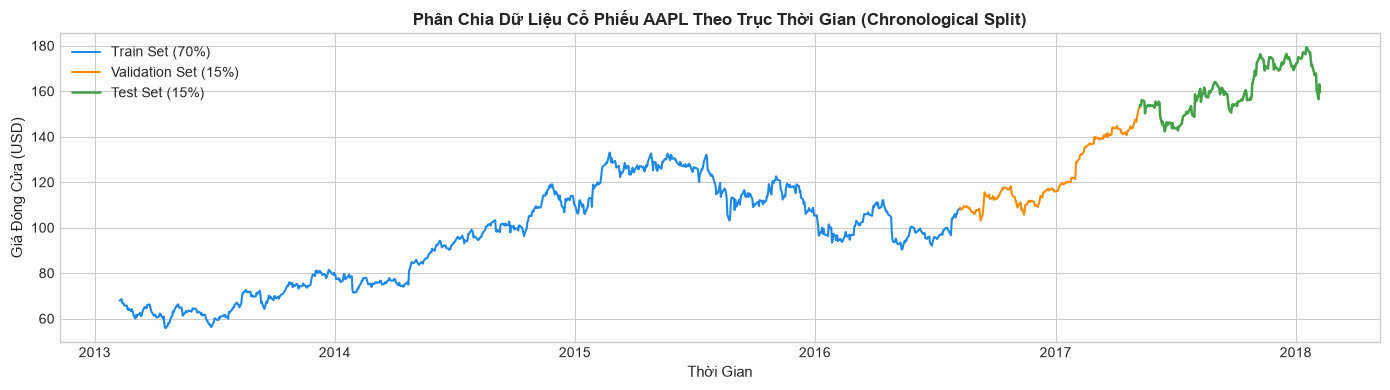

In [6]:
# Thực hiện chia Train/Val/Test theo thứ tự thời gian nghiêm ngặt
feature_cols = ['open', 'high', 'low', 'close', 'volume']
target_col = 'close'

# Trích xuất mảng dữ liệu đặc trưng và nhãn
data_values = df_aapl[feature_cols].values
dates = df_aapl['date'].values

n_total = len(df_aapl)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

train_data = data_values[:n_train]
val_data = data_values[n_train : n_train + n_val]
test_data = data_values[n_train + n_val :]

train_dates = dates[:n_train]
val_dates = dates[n_train : n_train + n_val]
test_dates = dates[n_train + n_val :]

print("=== KẾT QUẢ PHÂN CHIA TẬP DỮ LIỆU THEO THỜI GIAN ===")
print(f"Tổng số ngày quan sát : {n_total} ngày (100%)")
print(f"1. Tập Train (70%)     : {len(train_data):<4} ngày | Từ {pd.to_datetime(train_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(train_dates[-1]).strftime('%Y-%m-%d')}")
print(f"2. Tập Validation (15%): {len(val_data):<4} ngày | Từ {pd.to_datetime(val_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(val_dates[-1]).strftime('%Y-%m-%d')}")
print(f"3. Tập Test (15%)      : {len(test_data):<4} ngày | Từ {pd.to_datetime(test_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(test_dates[-1]).strftime('%Y-%m-%d')}")

# Vẽ biểu đồ phân đoạn thời gian trực quan
plt.figure(figsize=(14, 4))
plt.plot(train_dates, train_data[:, 3], label='Train Set (70%)', color='#1E88E5', linewidth=1.5)
plt.plot(val_dates, val_data[:, 3], label='Validation Set (15%)', color='#FB8C00', linewidth=1.5)
plt.plot(test_dates, test_data[:, 3], label='Test Set (15%)', color='#43A047', linewidth=1.8)
plt.title("Phân Chia Dữ Liệu Cổ Phiếu AAPL Theo Trục Thời Gian (Chronological Split)", fontsize=12, fontweight='bold')
plt.xlabel("Thời Gian", fontsize=11)
plt.ylabel("Giá Đóng Cửa (USD)", fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
<a id="section-7"></a>
## 7. Chuẩn Hóa Dữ Liệu (Scaling) & Phòng Chống Data Leakage

### 7.1. Lựa chọn Scaler phù hợp:
Trong bài toán hồi quy mạng nơ-ron RNN với hàm kích hoạt $\tanh$:
* Chúng ta sử dụng **`MinMaxScaler(feature_range=(0, 1))`**.
* Công thức biến đổi:
  $$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$
* Lý do: Giảm chênh lệch thang đo giữa giá và volume. MinMaxScaler không biến mặt loss thành mặt cầu hay bảo đảm hội tụ; chỉ Train nằm trong [0,1], Val/Test có thể vượt khoảng này.

---

### 7.2. Nguyên tắc sống còn: Chỉ FIT trên tập Train!
* **Quy trình đúng**:
  ```python
  scaler.fit(train_data)                    # CHỈ học min, max từ tập Train!
  scaled_train = scaler.transform(train_data)
  scaled_val   = scaler.transform(val_data)   # Dùng min, max của Train để scale Val!
  scaled_test  = scaler.transform(test_data)  # Dùng min, max của Train để scale Test!
  ```
* **Tại sao không được fit trên toàn bộ dataset?**
  * Nếu ta gọi `scaler.fit(toàn_bộ_dataset)`, giá trị $x_{\max}$ và $x_{\min}$ của năm 2018 (tương lai) sẽ được đưa vào công thức chuẩn hóa của năm 2013 (quá khứ). 
  * Mô hình sẽ gián tiếp biết được mức giá trần và giá sàn của tương lai $\implies$ Rò rỉ thông tin tương lai (*Look-ahead Data Leakage*).
* Ngoài ra, ta tạo riêng một **`target_scaler`** dành riêng cho cột `close` để sau này có thể dễ dàng gọi hàm `.inverse_transform()` chuyển đổi các dự báo $\hat{y}$ về đơn vị tiền tệ USD gốc.


In [7]:
# Thực hiện chuẩn hóa dữ liệu bằng MinMaxScaler tuân thủ nguyên tắc chống Data Leakage
from sklearn.preprocessing import MinMaxScaler

# 1. Scaler cho toàn bộ 5 đặc trưng đầu vào (Input Scaler)
feature_scaler = MinMaxScaler(feature_range=(0, 1))

# FIT CHỈ TRÊN TẬP TRAIN
feature_scaler.fit(train_data)

# Transform độc lập trên từng tập
scaled_train_x = feature_scaler.transform(train_data)
scaled_val_x   = feature_scaler.transform(val_data)
scaled_test_x  = feature_scaler.transform(test_data)

# 2. Scaler riêng cho cột mục tiêu 'close' (Target Scaler - cột index 3)
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(train_data[:, [3]])  # Cột index 3 là 'close'

print("=== KIỂM TRA THÔNG SỐ CỦA SCALER (HỌC TỪ TẬP TRAIN) ===")
for col, min_val, max_val in zip(feature_cols, feature_scaler.data_min_, feature_scaler.data_max_):
    print(f"Đặc trưng {col:<8}: Min = {min_val:>12.2f} | Max = {max_val:>12.2f}")

print("\nKiểm tra khoảng giá trị sau khi scale trên tập Train:")
print(f"Train Scaled Min: {scaled_train_x.min():.4f}, Max: {scaled_train_x.max():.4f}")
print("Kiểm tra khoảng giá trị trên tập Test (có thể hơi vượt [0, 1] nếu giá tương lai bứt phá đỉnh):")
print(f"Test Scaled Min : {scaled_test_x.min():.4f}, Max: {scaled_test_x.max():.4f}")


=== KIỂM TRA THÔNG SỐ CỦA SCALER (HỌC TỪ TẬP TRAIN) ===
Đặc trưng open    : Min =        55.42 | Max =       134.46
Đặc trưng high    : Min =        57.09 | Max =       134.54
Đặc trưng low     : Min =        55.01 | Max =       131.40
Đặc trưng close   : Min =        55.79 | Max =       133.00
Đặc trưng volume  : Min =  13046445.00 | Max = 266833581.00

Kiểm tra khoảng giá trị sau khi scale trên tập Train:
Train Scaled Min: 0.0000, Max: 1.0000
Kiểm tra khoảng giá trị trên tập Test (có thể hơi vượt [0, 1] nếu giá tương lai bứt phá đỉnh):
Test Scaled Min : 0.0039, Max: 1.6133


---
<a id="section-8"></a>
## 8. Tạo Cấu Trúc Cửa Sổ Trượt (Sliding Windows)

Sau khi dữ liệu đã được chuẩn hóa theo trật tự thời gian, bước tiếp theo là chuyển đổi mảng dữ liệu 2D phẳng thành các mẫu **Tensor 3D** phục vụ cho mô hình RNN:

### 8.1. Cấu trúc kích thước mong muốn:
* **Ma trận đầu vào $X$**: Kích thước `(num_samples, sequence_length, num_features)` $\implies (M, 20, 5)$.
* **Vector nhãn mục tiêu $y$**: Kích thước `(num_samples,)` $\implies (M,)$.

---

### 8.2. Hàm tạo sliding window tổng quát:
Hàm `create_sliding_sequences` nhận vào mảng 2D và chỉ số cột mục tiêu, trượt cửa sổ $L = 20$ bước, lấy giá trị `close` tại bước kế tiếp $t + 1$ làm nhãn.

> **Giao thức**: Cửa sổ được tạo riêng trong mỗi split; 20 phiên đầu mỗi split làm context. Test có **170 target từ 07/06/2017 đến 07/02/2018**, dự báo từng bước với lịch sử thực đã quan sát, chưa phải dự báo đệ quy toàn bộ giai đoạn.


In [8]:
# Xây dựng hàm tạo chuỗi sliding window cho dữ liệu chuỗi thời gian
def create_sliding_sequences(data_array, target_idx=3, seq_length=20):
    """
    Tạo các cặp (X, y) từ mảng chuỗi thời gian.
    
    Tham số:
        data_array (np.ndarray): Mảng 2D shape (N, num_features).
        target_idx (int): Vị trí cột làm target (3 là 'close').
        seq_length (int): Độ dài cửa sổ quan sát quá khứ (L = 20).
        
    Trả về:
        X (np.ndarray): Mảng 3D shape (N - seq_length, seq_length, num_features).
        y (np.ndarray): Mảng 1D shape (N - seq_length,).
    """
    X, y = [], []
    num_records = len(data_array)
    
    for i in range(num_records - seq_length):
        # Lấy seq_length dòng liên tiếp làm đặc trưng
        seq_x = data_array[i : i + seq_length, :]
        # Lấy giá trị target tại dòng tiếp theo ngay sau cửa sổ
        target_val = data_array[i + seq_length, target_idx]
        
        X.append(seq_x)
        y.append(target_val)
        
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

seq_len = 20

# Áp dụng hàm trên từng tập dữ liệu đã chuẩn hóa
X_train, y_train = create_sliding_sequences(scaled_train_x, target_idx=3, seq_length=seq_len)
X_val,   y_val   = create_sliding_sequences(scaled_val_x,   target_idx=3, seq_length=seq_len)
X_test,  y_test  = create_sliding_sequences(scaled_test_x,  target_idx=3, seq_length=seq_len)

print("=== KÍCH THƯỚC DỮ LIỆU SAU KHI TẠO SLIDING WINDOW ===")
print(f"Tập Train     : X shape = {X_train.shape} | y shape = {y_train.shape}")
print(f"Tập Validation: X shape = {X_val.shape}   | y shape = {y_val.shape}")
print(f"Tập Test      : X shape = {X_test.shape}   | y shape = {y_test.shape}\n")

# In kiểm tra mẫu đầu tiên trong tập Train
print("=== CHI TIẾT MẪU ĐẦU TIÊN (SAMPLE INDEX 0) ===")
print(f"Cửa sổ X[0] gồm {X_train[0].shape[0]} bước thời gian, mỗi bước có {X_train[0].shape[1]} đặc trưng.")
print("3 bước thời gian đầu tiên trong cửa sổ X[0]:\n", X_train[0][:3])
print("\nBước thời gian cuối cùng trong cửa sổ X[0] (t = 19):\n", X_train[0][-1])
print(f"\nGiá trị mục tiêu tương ứng y[0] (t = 20, đặc trưng 'close' đã scale): {y_train[0]:.4f}")
print(f"-> Quy đổi ngược về giá thực tế USD: ${target_scaler.inverse_transform([[y_train[0]]])[0][0]:.2f}")


# Kiểm chứng cửa sổ: nhãn luôn là bước ngay sau input; scaler chỉ fit Train.
for split_x, split_y, scaled in [(X_train, y_train, scaled_train_x), (X_val, y_val, scaled_val_x), (X_test, y_test, scaled_test_x)]:
    assert split_x.shape == (len(scaled) - seq_len, seq_len, len(feature_cols))
    assert np.isfinite(split_x).all() and np.isfinite(split_y).all()
    np.testing.assert_allclose(split_x[0], scaled[:seq_len], rtol=1e-6, atol=1e-7)
    np.testing.assert_allclose(split_y, scaled[seq_len:, 3], rtol=1e-6, atol=1e-7)
np.testing.assert_allclose(feature_scaler.data_min_, train_data.min(axis=0))
np.testing.assert_allclose(feature_scaler.data_max_, train_data.max(axis=0))
assert train_dates[-1] < val_dates[0] and val_dates[-1] < test_dates[0]
print("-> Đã kiểm chứng shape, thứ tự thời gian, căn chỉnh nhãn và scaler Train.")


=== KÍCH THƯỚC DỮ LIỆU SAU KHI TẠO SLIDING WINDOW ===
Tập Train     : X shape = (861, 20, 5) | y shape = (861,)
Tập Validation: X shape = (168, 20, 5)   | y shape = (168,)
Tập Test      : X shape = (170, 20, 5)   | y shape = (170,)

=== CHI TIẾT MẪU ĐẦU TIÊN (SAMPLE INDEX 0) ===
Cửa sổ X[0] gồm 20 bước thời gian, mỗi bước có 5 đặc trưng.
3 bước thời gian đầu tiên trong cửa sổ X[0]:
 [[0.155509   0.14609519 0.15550797 0.15625288 0.57182556]
 [0.16002876 0.1574012  0.16485918 0.16541229 0.4570089 ]
 [0.16546966 0.15267971 0.15456145 0.14315355 0.5468477 ]]

Bước thời gian cuối cùng trong cửa sổ X[0] (t = 19):
 [0.07561229 0.06608413 0.08137245 0.07621153 0.3341698 ]

Giá trị mục tiêu tương ứng y[0] (t = 20, đặc trưng 'close' đã scale): 0.0876
-> Quy đổi ngược về giá thực tế USD: $62.55
-> Đã kiểm chứng shape, thứ tự thời gian, căn chỉnh nhãn và scaler Train.


---
<a id="section-9"></a>
## 9. Xây Dựng PyTorch Dataset & DataLoader

Để mô hình PyTorch có thể nạp dữ liệu hiệu quả theo lô (Mini-batch) và tự động quản lý bộ nhớ GPU/CPU, chúng ta đóng gói các mảng NumPy $(X, y)$ thành:
1. **Lớp `StockDataset` tùy biến (Custom `torch.utils.data.Dataset`)**: Quản lý việc chuyển đổi mảng số NumPy sang PyTorch Tensors kiểu `torch.float32`.
2. **`torch.utils.data.DataLoader`**: 
   * Tự động gom mẫu thành các lô (`batch_size = 32`).
   * **Lưu ý về Shuffle**:
     * Đối với **Train**: Có thể xáo trộn các cửa sổ độc lập sau khi chia split; không đảo thứ tự bên trong cửa sổ. Bài giữ `shuffle=False` để dễ đối chiếu. Hidden state reset theo mỗi cửa sổ, không truyền liên tục giữa các batch.
     * Đối với tập **Validation** và **Test**: **Bắt buộc `shuffle=False`** để đồ thị dự báo vẽ ra khớp chính xác với dòng thời gian thực tế!


In [9]:
# Xây dựng PyTorch Dataset và DataLoader hoàn chỉnh
import torch
from torch.utils.data import Dataset, DataLoader

class StockDataset(Dataset):
    """
    PyTorch Dataset tùy biến để nạp các chuỗi thời gian chứng khoán.
    """
    def __init__(self, X, y):
        # Chuyển đổi sang PyTorch FloatTensor
        self.X = torch.tensor(X, dtype=torch.float32)
        # Giữ y ở dạng vector (N, 1) hoặc (N,)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Khởi tạo các Dataset
train_dataset = StockDataset(X_train, y_train)
val_dataset   = StockDataset(X_val, y_val)
test_dataset  = StockDataset(X_test, y_test)

# Cấu hình Batch Size
BATCH_SIZE = 32

# Khởi tạo DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("=== KIỂM TRA PYTORCH DATALOADER ===")
print(f"Batch size: {BATCH_SIZE}")
print(f"Số lượng batches trong Train Loader: {len(train_loader)} batches ({len(train_dataset)} mẫu)")
print(f"Số lượng batches trong Val Loader  : {len(val_loader)} batches ({len(val_dataset)} mẫu)")
print(f"Số lượng batches trong Test Loader : {len(test_loader)} batches ({len(test_dataset)} mẫu)\n")

# Lấy thử 1 batch đầu tiên từ train_loader để kiểm tra shape
first_batch_x, first_batch_y = next(iter(train_loader))

print("=== THÔNG SỐ TENSOR CỦA BATCH ĐẦU TIÊN ===")
print(f"Batch X Shape: {first_batch_x.shape} -> (batch_size, sequence_length, num_features)")
print(f"Batch y Shape: {first_batch_y.shape}  -> (batch_size, target_size)")
print(f"Kiểu dữ liệu X: {first_batch_x.dtype} | Kiểu dữ liệu y: {first_batch_y.dtype}")


=== KIỂM TRA PYTORCH DATALOADER ===
Batch size: 32
Số lượng batches trong Train Loader: 27 batches (861 mẫu)
Số lượng batches trong Val Loader  : 6 batches (168 mẫu)
Số lượng batches trong Test Loader : 6 batches (170 mẫu)

=== THÔNG SỐ TENSOR CỦA BATCH ĐẦU TIÊN ===
Batch X Shape: torch.Size([32, 20, 5]) -> (batch_size, sequence_length, num_features)
Batch y Shape: torch.Size([32, 1])  -> (batch_size, target_size)
Kiểu dữ liệu X: torch.float32 | Kiểu dữ liệu y: torch.float32


---
<a id="section-10"></a>
## 10. Ready for PyTorch RNN (Bảng Tổng Kết & Sẵn Sàng Huấn Luyện)

Toàn bộ quy trình nạp dữ liệu, phân tích khám phá (EDA), làm sạch, phân chia thời gian, chuẩn hóa và đóng gói tensor đã hoàn tất với độ chính xác cao. Dưới đây là bảng tổng kết chi tiết thông số kỹ thuật sẵn sàng cho mô hình RNN ở Phần 2:

### Bảng Thông Số Kỹ Thuật (Data Specifications):

| Tiêu chí kỹ thuật | Giá trị cấu hình | Ý nghĩa & Mô tả chi tiết |
| :--- | :--- | :--- |
| **Mã cổ phiếu lựa chọn** | `AAPL` (Apple Inc.) | 1,259 phiên giao dịch liên tục, đầy đủ, không rỗng, có dữ liệu OHLCV đầy đủ. |
| **Khoảng thời gian** | 2013-02-08 $\to$ 2018-02-07 | 5 năm quan sát giá và khối lượng của AAPL. |
| **Sequence Length ($L$)** | **20 ngày giao dịch** | Xấp xỉ 1 tháng giao dịch trên thị trường tài chính Mỹ. |
| **Number of Features ($D$)** | **5 đặc trưng** | Bao gồm đầy đủ `['open', 'high', 'low', 'close', 'volume']`. |
| **Target Variable ($y$)** | **`close` tại bước $t+1$** | Giá đóng cửa phiên kế tiếp (USD) — Chuẩn mực định giá đầu tư. |
| **Phương pháp chuẩn hóa** | `MinMaxScaler(0, 1)` | Fit trên tập Train, Transform trên Val/Test để chống Data Leakage. |
| **Quy chuẩn Input Tensor** | `(batch_size, 20, 5)` | 3D Tensor hoàn toàn tương thích với cờ `batch_first=True` của `torch.nn.RNN`. |
| **Quy chuẩn Target Tensor** | `(batch_size, 1)` | Giá trị thực liên tục cho bài toán Hồi quy (Regression). |
| **Kích thước tập Train** | **861 mẫu** ($861$ chuỗi thời gian $20$ ngày) | Dùng để cập nhật tham số mạng nơ-ron qua thuật toán BPTT. |
| **Kích thước tập Val** | **168 mẫu** ($168$ chuỗi thời gian $20$ ngày) | Dùng để chọn epoch có validation loss nhỏ nhất. |
| **Kích thước tập Test** | **170 mẫu** ($170$ chuỗi thời gian $20$ ngày) | Dùng để đánh giá độc lập mô hình cuối cùng trên dữ liệu thực. |
| **Batch Size cấu hình** | **32** | Tối ưu hóa tính toán ma trận song song trên phần cứng. |

---

### Xác nhận trạng thái:
* Dữ liệu hoàn toàn sạch, không chứa giá trị `NaN` hay `Inf`.
* Không xảy ra rò rỉ dữ liệu giữa quá khứ và tương lai.
* Cả 3 DataLoader (`train_loader`, `val_loader`, `test_loader`) đã sẵn sàng.


# PHẦN 2: XÂY DỰNG, HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH PYTORCH RNN

---

Trong phần này, chúng ta bước vào giai đoạn cốt lõi của bài toán học sâu chuỗi thời gian:
1. **Thiết lập tính tái lập (Reproducibility)**: Cố định hạt giống ngẫu nhiên (Random Seed) trên Python, NumPy, PyTorch và xác định thiết bị tính toán phần cứng.
2. **Xây dựng kiến trúc mô hình Vanilla RNN**: Sử dụng thuần túy `torch.nn.RNN` theo luồng `Input -> RNN -> Linear -> Prediction` (không sử dụng LSTM/GRU), giải thích tường tận từng tham số và luồng biến đổi tensor.
3. **Cấu hình Loss & Optimizer**: Giải thích lý do lựa chọn `MSELoss` và `Adam`.
4. **Viết Training Loop chuẩn mực**: Tích hợp đầy đủ các bước forward, loss, zero_grad, backward, optimizer.step() và theo dõi Validation mỗi epoch.
5. **Trực quan hóa Loss Curve**: Phân tích khả năng học và kiểm chứng dấu hiệu Overfitting.
6. **Thực hiện dự đoán & Đánh giá định lượng**: Khôi phục thang đo giá gốc (`inverse_transform`), đo lường qua các thước đo MAE, MSE, RMSE, MAPE, $R^2$.
7. **Trực quan hóa Thực tế vs Dự đoán**: Quan sát độ bám xu hướng và độ trễ pha (Phase lag).
8. **Phân tích chuyên sâu & Cảnh báo rủi ro**: Nhận định về giới hạn của RNN, lý do thị trường chứng khoán là bài toán cực kỳ thách thức (EMH, Noise), và đưa ra kết luận toàn diện.


---
<a id="section-11"></a>
## 11. Reproducibility & Thiết Lập Môi Trường (Random Seed, Device, Version)

Trong nghiên cứu Học sâu (Deep Learning) và Khoa học Dữ liệu, **tính tái lập (Reproducibility)** là yếu tố sống còn. Do quá trình khởi tạo trọng số ngẫu nhiên của các ma trận $W_{ih}, W_{hh}, W_{fc}$ có thể dẫn đến kết quả huấn luyện khác nhau giữa các lần chạy, chúng ta cần:
1. **Cố định Seed ngẫu nhiên**: Khóa seed trên cả `random`, `numpy`, và `torch` (kể cả CUDA nếu có GPU).
2. **Kiểm tra thiết bị tính toán (Hardware Device)**: Tự động phát hiện GPU CUDA hoặc sử dụng CPU.
3. **In phiên bản phần mềm**: Ghi nhận PyTorch version để đảm bảo tính tương thích lâu dài.


In [10]:
# Thiết lập tính tái lập (Reproducibility) và xác định thiết bị tính toán
import random
import torch
import torch.nn as nn
import numpy as np

def set_seed(seed=42):
    """
    Cố định hạt giống ngẫu nhiên trên toàn bộ các thư viện để đảm bảo kết quả có thể tái lập trong cùng môi trường thực thi.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Thực thi cố định seed
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

# Xác định thiết bị thực thi (CPU hoặc CUDA GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=== THÔNG TIN MÔI TRƯỜNG THỰC THI & TÍNH TÁI LẬP (REPRODUCIBILITY) ===")
print(f"PyTorch Version   : {torch.__version__}")
print(f"Thiết bị tính toán: {device}")
if torch.cuda.is_available():
    print(f"Tên GPU           : {torch.cuda.get_device_name(0)}")
else:
    print("Chế độ            : CPU Execution (Mô hình RNN tối giản chạy rất nhanh trên CPU)")
print(f"Random Seed       : {RANDOM_SEED} (Đã thiết lập thành công)")


=== THÔNG TIN MÔI TRƯỜNG THỰC THI & TÍNH TÁI LẬP (REPRODUCIBILITY) ===
PyTorch Version   : 2.14.0+cpu
Thiết bị tính toán: cpu
Chế độ            : CPU Execution (Mô hình RNN tối giản chạy rất nhanh trên CPU)
Random Seed       : 42 (Đã thiết lập thành công)


---
<a id="section-12"></a>
## 12. Xây Dựng RNN Model Với PyTorch (`torch.nn.RNN`)

Chúng ta xây dựng một mô hình **Vanilla RNN tối giản**, được thiết kế đặc biệt phù hợp cho người mới bắt đầu học mạng nơ-ron hồi quy, tuân thủ nghiêm ngặt nguyên tắc: **Sử dụng thuần túy `torch.nn.RNN`, tuyệt đối không tự ý thay đổi sang LSTM hay GRU**.

---

### 12.1. Cấu trúc mô hình tổng quát:
$$\text{Input } X \in \mathbb{R}^{B \times 20 \times 5} \longrightarrow \mathbf{\text{torch.nn.RNN}} \longrightarrow \text{Hidden State Cuối } h_{20} \in \mathbb{R}^{B \times 32} \longrightarrow \mathbf{\text{nn.Linear}} \longrightarrow \hat{y} \in \mathbb{R}^{B \times 1}$$

---

### 12.2. Giải thích chi tiết các thành phần và tham số cốt lõi:

1. **`input_size` ($D = 5$)**:
   * Số lượng đặc trưng đầu vào tại mỗi bước thời gian $t$.
   * Tại mỗi ngày giao dịch, mô hình tiếp nhận một vector 5 chiều gồm: $[\text{open}, \text{high}, \text{low}, \text{close}, \text{volume}]$.

2. **`hidden_size` ($H = 32$)**:
   * Số chiều của vector trạng thái ẩn $h_t$ (Hidden State).
   * $H=32$ là cấu hình ban đầu với số tham số nhỏ; chưa có đối chứng để kết luận đủ dung lượng hoặc tối ưu.

3. **`num_layers` ($= 1$)**:
   * Số lượng tầng RNN xếp chồng (Stacked RNN).
   * Ta chọn mô hình 1 tầng cơ bản. Tầng này trực tiếp nhận dữ liệu chuỗi thô và xuất ra biểu diễn đặc trưng thời gian.

4. **`batch_first = True`**:
   * Tham số quan trọng trong PyTorch xác định trật tự các trục của Tensor.
   * Khi `batch_first=True`, Tensor đầu vào có định dạng `(batch_size, sequence_length, input_size)` $\implies (B, 20, 5)$.
   * Nếu để mặc định `False`, PyTorch yêu cầu định dạng `(sequence_length, batch_size, input_size)`, rất dễ gây nhầm lẫn khi làm việc với `DataLoader` và thư viện dữ liệu tiêu chuẩn.

5. **`output` (Đầu ra của lớp RNN)**:
   * Khi gọi `rnn_out, h_n = self.rnn(x)`, biến `rnn_out` có kích thước `(batch_size, sequence_length, hidden_size)` $\implies (B, 20, 32)$.
   * `rnn_out` chứa toàn bộ chuỗi trạng thái ẩn tại mọi bước thời gian: $[h_1, h_2, \dots, h_{20}]$.

6. **`hidden state` ($h_t$ và $h_n$)**:
   * Trạng thái ẩn $h_t \in \mathbb{R}^{32}$ là "trái tim" của mạng RNN, được cập nhật tuần tự theo công thức:
     $$h_t = \tanh(W_{ih} x_t + b_{ih} + W_{hh} h_{t-1} + b_{hh})$$
   * `h_n` là trạng thái ẩn tại bước thời gian cuối cùng của mỗi tầng RNN, có kích thước `(num_layers, batch_size, hidden_size)`.
   * Dùng biểu diễn học được từ 20 phiên trước tại `rnn_out[:, -1, :]` (tương đương `h_n[-1]` với một tầng, một chiều); không bảo đảm giữ nguyên toàn bộ thông tin đầu vào.

7. **`Linear layer` (`nn.Linear(hidden_size, output_size)`)**:
   * Lớp Fully Connected (Dense layer) nhận vector 32 chiều từ trạng thái ẩn cuối cùng và thực hiện phép biến đổi tuyến tính:
     $$\hat{y} = W_{fc} \cdot h_{20} + b_{fc}$$
   * Vì bài toán là hồi quy đơn biến (dự đoán 1 mức giá đóng cửa $\hat{y}$), ta đặt `output_size = 1`.


In [11]:
# Xây dựng lớp mô hình StockRNN tối giản bằng PyTorch
class StockRNN(nn.Module):
    """
    Mô hình Vanilla RNN tối giản cho bài toán hồi quy chuỗi thời gian giá cổ phiếu.
    Kiến trúc: Input (B, 20, 5) -> RNN (Tanh) -> Linear(32, 1) -> Output (B, 1)
    """
    def __init__(self, input_size=5, hidden_size=32, num_layers=1, output_size=1):
        super(StockRNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 1. Tầng hồi quy Vanilla RNN với hàm kích hoạt tanh
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh'
        )
        
        # 2. Tầng tuyến tính Fully Connected dự đoán giá đóng cửa phiên tiếp theo
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # x shape: (batch_size, sequence_length=20, input_size=5)
        # PyTorch tự động khởi tạo hidden state h_0 ban đầu là vector 0 nếu không truyền vào
        rnn_out, h_n = self.rnn(x)
        
        # rnn_out shape: (batch_size, sequence_length=20, hidden_size=32)
        # Trích xuất trạng thái ẩn tại bước thời gian cuối cùng (bước thứ 20, index = -1)
        last_hidden = rnn_out[:, -1, :]  # shape: (batch_size, hidden_size=32)
        
        # Ánh xạ qua lớp tuyến tính Linear để đưa ra giá trị dự đoán liên tục
        prediction = self.fc(last_hidden)  # shape: (batch_size, 1)
        return prediction

# Khởi tạo instance của mô hình và chuyển sang thiết bị tính toán
model = StockRNN(input_size=5, hidden_size=32, num_layers=1, output_size=1).to(device)

print("=== KIẾN TRÚC MÔ HÌNH PYTORCH VANILLA RNN ===")
print(model)

# Đếm tổng số lượng tham số học được (Trainable Parameters)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTổng số tham số học được (Trainable Parameters): {total_params:,}")

# Giải thích chi tiết cách tính số lượng tham số:
# 1. Tầng RNN:
#    - Ma trận trọng số đầu vào W_ih: (hidden_size, input_size)  = 32 * 5  = 160
#    - Ma trận trọng số hồi quy W_hh: (hidden_size, hidden_size) = 32 * 32 = 1,024
#    - Bias đầu vào b_ih            : hidden_size               = 32
#    - Bias hồi quy b_hh            : hidden_size               = 32
#    -> Tổng tham số tầng RNN = 160 + 1,024 + 32 + 32 = 1,248 tham số.
# 2. Tầng Tuyến Tính (Linear):
#    - Ma trận trọng số W_fc        : (output_size, hidden_size) = 1 * 32 = 32
#    - Bias b_fc                    : output_size                = 1
#    -> Tổng tham số tầng Linear = 32 + 1 = 33 tham số.
# => Tổng cộng toàn mạng: 1,248 + 33 = 1,281 tham số.
print(f"-> Kiểm chứng lý thuyết: 1,248 (RNN) + 33 (Linear) = 1,281 tham số. (Khớp: {total_params == 1281})")


=== KIẾN TRÚC MÔ HÌNH PYTORCH VANILLA RNN ===
StockRNN(
  (rnn): RNN(5, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Tổng số tham số học được (Trainable Parameters): 1,281
-> Kiểm chứng lý thuyết: 1,248 (RNN) + 33 (Linear) = 1,281 tham số. (Khớp: True)


---
<a id="section-13"></a>
## 13. Lựa Chọn Hàm Mất Mát (Loss) & Thuật Toán Tối Ưu (Optimizer)

### 13.1. Lựa chọn Hàm mất mát (Loss Function): `nn.MSELoss()`
* **Bản chất toán học**:
  $$\text{MSE}(y, \hat{y}) = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
* **Giải thích lý do lựa chọn**:
  1. **Phù hợp với bài toán hồi quy (Regression)**: Biến mục tiêu là giá đóng cửa thực tế liên tục ($y \in \mathbb{R}$). MSE là hàm mất mát tiêu chuẩn vàng cho bài toán ước lượng giá trị thực.
  2. **Phạt nặng sai số lớn**: MSE tăng theo bình phương sai số, nên các dự báo lệch nhiều tác động mạnh tới mục tiêu tối ưu. Điều đó không bảo đảm mô hình tránh được rủi ro tài chính.
  3. **Tính khả vi**: $\partial\mathrm{MSE}/\partial\hat y_i=2(\hat y_i-y_i)/N$. Hàm lồi theo dự báo nhưng nhìn chung không lồi theo trọng số RNN; gradient BPTT vẫn có thể suy giảm hoặc tăng mạnh.

---

### 13.2. Lựa chọn Thuật toán tối ưu (Optimizer): `torch.optim.Adam`
* **Giải thích lý do lựa chọn**:
  1. **Tốc độ học thích ứng riêng cho từng trọng số (Adaptive Learning Rates)**: Adam (Adaptive Moment Estimation) duy trì hai thống kê riêng biệt cho từng tham số: mô-men bậc 1 (kỳ vọng gradient $m_t$) và mô-men bậc 2 (mô-men bậc hai không định tâm của gradient $v_t$). Các trọng số ít khi xuất hiện gradient lớn sẽ được tăng tốc, trong khi các trọng số biến động mạnh sẽ được điều tiết learning rate nhỏ lại.
  2. **Quán tính và thích ứng**: Các mô-men giúp điều chỉnh cập nhật theo lịch sử gradient, nhưng không bảo đảm thoát cực tiểu hay luôn nhanh hơn SGD.
  3. **Cấu hình thực nghiệm**: Learning rate 0.001 được giữ làm cấu hình ban đầu; đánh giá hội tụ dựa trên loss thực tế và chọn epoch bằng validation.


In [12]:
# Khởi tạo Loss Function và Optimizer
LEARNING_RATE = 0.001

# Hàm mất mát MSE cho bài toán hồi quy
criterion = nn.MSELoss()

# Thuật toán tối ưu Adam với learning rate thích ứng
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("=== THIẾT LẬP LOSS FUNCTION & OPTIMIZER ===")
print(f"Hàm mất mát (Criterion): {criterion.__class__.__name__}")
print(f"Thuật toán tối ưu      : {optimizer.__class__.__name__}")
print(f"Tốc độ học khởi tạo    : {LEARNING_RATE}")
print(f"Tham số tối ưu         : betas=(0.9, 0.999), eps=1e-08")


=== THIẾT LẬP LOSS FUNCTION & OPTIMIZER ===
Hàm mất mát (Criterion): MSELoss
Thuật toán tối ưu      : Adam
Tốc độ học khởi tạo    : 0.001
Tham số tối ưu         : betas=(0.9, 0.999), eps=1e-08


---
<a id="section-14"></a>
## 14. Quy Trình Huấn Luyện (Training Loop) Hoàn Chỉnh

Một chu trình huấn luyện mạng nơ-ron PyTorch chuẩn mực bao gồm 5 bước toán học cốt lõi trong mỗi batch:
1. **`forward`**: Đưa mini-batch $X$ qua mạng để tính toán giá trị dự đoán $\hat{y} = \text{model}(X)$.
2. **`loss`**: Tính toán độ sai lệch $L = \text{criterion}(\hat{y}, y)$.
3. **`zero_grad`**: Xóa sạch toàn bộ gradient tích lũy từ bước trước (`optimizer.zero_grad()`).
4. **`backward`**: Lan truyền ngược qua thời gian (BPTT - Backpropagation Through Time) để tính toán đạo hàm riêng của Loss theo từng tham số (`loss.backward()`).
5. **`optimizer.step()`**: Cập nhật các trọng số theo hướng dốc xuống của gradient.

---

### Quy tắc bảo toàn logic chuỗi thời gian:
* **Không xáo trộn gây sai lệch (Strict Time Series Logic)**:
  * Trong toàn bộ quá trình, `val_loader` được giữ nguyên cấu hình `shuffle=False` để kiểm tra độ tin cậy của mô hình trên các mốc thời gian nối tiếp nhau.
  * Mỗi epoch đều thực hiện đánh giá Validation độc lập với cờ `model.eval()` và khối ngữ cảnh `with torch.no_grad():` để ngăn ngừa việc rò rỉ gradient và tiết kiệm bộ nhớ tính toán.

> **Chọn trọng số**: Chạy đủ 100 epoch, lưu bản sao trọng số tại mỗi lần `val_loss` đạt mức thấp mới và khôi phục bản tốt nhất trước dự đoán Test. Không dùng Test để chọn epoch. PyTorch không dừng sớm; Keras có EarlyStopping, nên đây chưa phải so sánh hai framework với ngân sách cập nhật giống hệt nhau.


In [13]:
# Viết và thực thi Training Loop hoàn chỉnh kèm Validation mỗi epoch
import time
from copy import deepcopy

EPOCHS = 100
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_epoch = 0
best_state = None

print(f"=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH TRÊN {EPOCHS} EPOCHS ===")
start_train_time = time.time()

for epoch in range(1, EPOCHS + 1):
    # -------------------------------------------------------------------------
    # 1. GIAI ĐOẠN HUẤN LUYỆN (TRAINING STEP)
    # -------------------------------------------------------------------------
    model.train()
    running_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        # Chuyển tensor sang thiết bị tính toán
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # Bước 1: Xóa sạch gradient tích lũy của batch trước
        optimizer.zero_grad()
        
        # Bước 2: Lan truyền tiến (Forward Pass)
        predictions = model(batch_x)
        
        # Bước 3: Tính toán hàm mất mát (Compute Loss)
        loss = criterion(predictions, batch_y)
        
        # Bước 4: Lan truyền ngược qua thời gian (Backward Pass / BPTT)
        loss.backward()
        
        # Bước 5: Cập nhật trọng số của mô hình (Optimizer Step)
        optimizer.step()
        
        # Tích lũy loss (nhân với số lượng mẫu trong batch hiện tại)
        running_train_loss += loss.item() * batch_x.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    
    # -------------------------------------------------------------------------
    # 2. GIAI ĐOẠN ĐÁNH GIÁ (VALIDATION STEP)
    # -------------------------------------------------------------------------
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for val_x, val_y in val_loader:
            val_x, val_y = val_x.to(device), val_y.to(device)
            val_preds = model(val_x)
            v_loss = criterion(val_preds, val_y)
            running_val_loss += v_loss.item() * val_x.size(0)
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch
        best_state = deepcopy(model.state_dict())
    
    # In thông tin tiến trình định kỳ mỗi 10 epoch hoặc ở epoch 1, epoch cuối
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"Epoch [{epoch:3d}/{EPOCHS}] | Train Loss (MSE): {epoch_train_loss:.6f} | Val Loss (MSE): {epoch_val_loss:.6f}")

total_duration = time.time() - start_train_time
print(f"\n-> Huấn luyện hoàn tất xuất sắc trong {total_duration:.2f} giây! ({total_duration / EPOCHS:.4f}s / epoch)")


# Khôi phục trọng số có validation loss nhỏ nhất; không chọn theo Test.
model.load_state_dict(best_state)
model.eval()
print(f"-> Khôi phục epoch {best_epoch}, Validation MSE tốt nhất = {best_val_loss:.6f}")


=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH TRÊN 100 EPOCHS ===


Epoch [  1/100] | Train Loss (MSE): 0.083737 | Val Loss (MSE): 0.021914


Epoch [ 10/100] | Train Loss (MSE): 0.002551 | Val Loss (MSE): 0.004936


Epoch [ 20/100] | Train Loss (MSE): 0.002161 | Val Loss (MSE): 0.003030


Epoch [ 30/100] | Train Loss (MSE): 0.001643 | Val Loss (MSE): 0.002280


...

Epoch [ 60/100] | Train Loss (MSE): 0.001172 | Val Loss (MSE): 0.001435


Epoch [ 70/100] | Train Loss (MSE): 0.001120 | Val Loss (MSE): 0.001312


Epoch [ 80/100] | Train Loss (MSE): 0.001084 | Val Loss (MSE): 0.001221


Epoch [ 90/100] | Train Loss (MSE): 0.001058 | Val Loss (MSE): 0.001150


Epoch [100/100] | Train Loss (MSE): 0.001036 | Val Loss (MSE): 0.001093

-> Huấn luyện hoàn tất xuất sắc trong 13.66 giây! (0.1366s / epoch)
-> Khôi phục epoch 100, Validation MSE tốt nhất = 0.001093


---
<a id="section-15"></a>
## 15. Theo Dõi Quá Trình Huấn Luyện & Phân Tích Loss (Overfitting Analysis)

Để đánh giá chất lượng học tập của mạng RNN, chúng ta lưu trữ toàn bộ lịch sử `train_losses` và `val_losses` qua từng epoch và vẽ biểu đồ đường cong mất mát (Loss Curve).

Đoạn code bên dưới sẽ vẽ biểu đồ song song trên cả thang đo tuyến tính (Linear Scale) và thang đo Logarit (Log Scale) để quan sát chi tiết sự hội tụ ở vùng loss cực nhỏ.


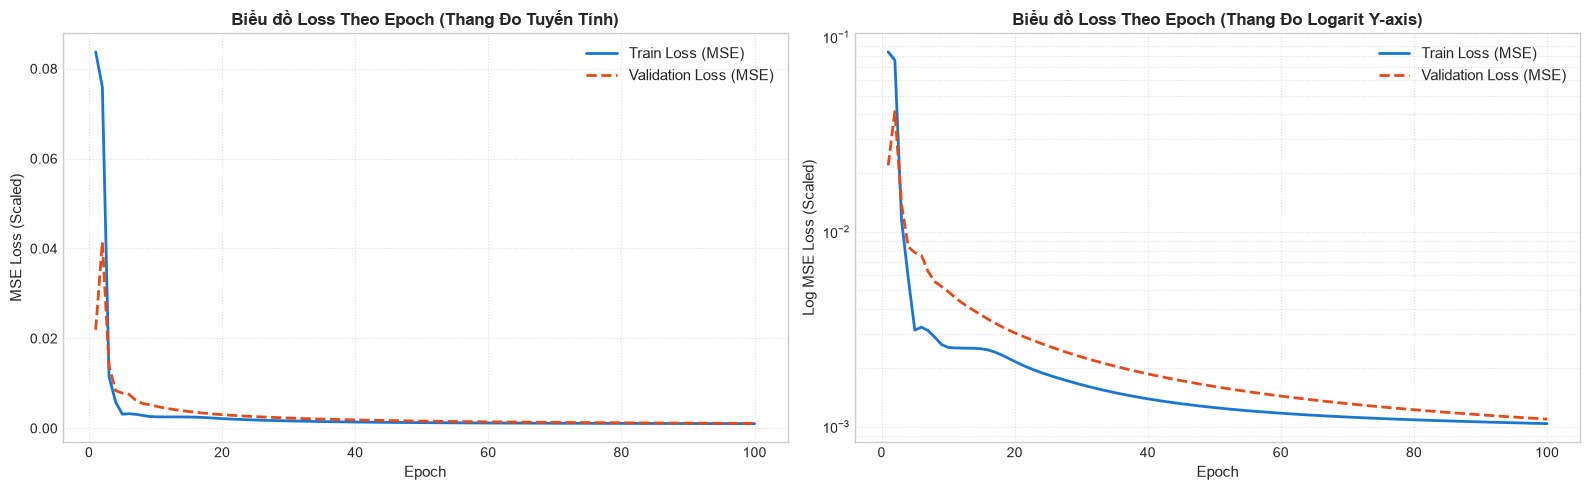

Loss ban đầu (Epoch 1)   : Train Loss = 0.083737 | Val Loss = 0.021914
Loss kết thúc (Epoch 100): Train Loss = 0.001036 | Val Loss = 0.001093
Tỷ lệ giảm Loss Train    : 98.76%


In [14]:
# Trực quan hóa đường cong hàm mất mát (Loss Curve) qua 100 Epochs
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

epochs_range = range(1, EPOCHS + 1)

# Biểu đồ 1: Thang đo tuyến tính thông thường
axes[0].plot(epochs_range, train_losses, label='Train Loss (MSE)', color='#1976D2', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Validation Loss (MSE)', color='#E64A19', linewidth=2, linestyle='--')
axes[0].set_title("Biểu đồ Loss Theo Epoch (Thang Đo Tuyến Tính)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("MSE Loss (Scaled)", fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Biểu đồ 2: Thang đo Logarit (Semi-log) quan sát rõ sự phân kỳ ở cực tiểu
axes[1].plot(epochs_range, train_losses, label='Train Loss (MSE)', color='#1976D2', linewidth=2)
axes[1].plot(epochs_range, val_losses, label='Validation Loss (MSE)', color='#E64A19', linewidth=2, linestyle='--')
axes[1].set_yscale('log')
axes[1].set_title("Biểu đồ Loss Theo Epoch (Thang Đo Logarit Y-axis)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Log MSE Loss (Scaled)", fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, which="both", linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Loss ban đầu (Epoch 1)   : Train Loss = {train_losses[0]:.6f} | Val Loss = {val_losses[0]:.6f}")
print(f"Loss kết thúc (Epoch 100): Train Loss = {train_losses[-1]:.6f} | Val Loss = {val_losses[-1]:.6f}")
print(f"Tỷ lệ giảm Loss Train    : {((train_losses[0] - train_losses[-1]) / train_losses[0]) * 100:.2f}%")


### Phân Tích Ý Nghĩa Biểu Đồ Loss:

#### 1. Mô hình học như thế nào qua các Epoch?
* Chạy **100 epoch**, chọn trọng số tại **epoch 100** theo validation. Train loss từ **0.083737** xuống **0.001036**; validation loss cuối **0.001093**, thấp nhất **0.001093**.
* Loss giảm cho thấy mô hình cải thiện mục tiêu MSE trên dữ liệu chuẩn hóa. Điều này chưa chứng minh đã khai thác hết năng lực kiến trúc hoặc đạt độ chính xác đủ tốt trên Test.

---

#### 2. Mô hình có dấu hiệu Overfitting (Học vẹt) hay không?
* Hai đường loss không cho thấy phân kỳ kéo dài rõ ở cuối lần chạy này. Tuy nhiên, không thể kết luận “hoàn toàn không overfitting” từ khoảng cách loss nhỏ.
* Các cửa sổ chồng lấp không phải các mẫu độc lập; validation và train thuộc các giai đoạn khác nhau. Loss Train được tích lũy trong lúc cập nhật, còn loss Validation tính với trọng số cuối epoch.
* Trọng số dùng dự đoán được chọn bằng validation; đánh giá khả năng tổng quát hóa phải dựa thêm vào Test và baseline ở Mục 17.


---
<a id="section-16"></a>
## 16. Dự Đoán Trên Test Set & Khôi Phục Thang Đo Gốc (Inverse Transform)

### 16.1. Quy trình dự đoán độc lập:
1. Đặt mô hình ở chế độ đánh giá (`model.eval()`).
2. Tắt chế độ tính toán đạo hàm tự động (`with torch.no_grad():`) để tiết kiệm bộ nhớ và tăng tốc xử lý.
3. Đưa toàn bộ các batch từ `test_loader` qua mô hình để thu thập mảng dự đoán $\hat{y}_{\text{scaled}}$.

---

### 16.2. Khôi phục về đơn vị giá gốc USD (`inverse_transform`):
* Mạng dùng dữ liệu đã chuẩn hóa theo min/max của Train; hidden state và đầu ra có miền giá trị riêng.
* Để các chỉ số đánh giá và trực quan hóa mang ý nghĩa kinh tế thực tế, chúng ta sử dụng `target_scaler.inverse_transform(...)` để ánh xạ các giá trị $\hat{y}$ và $y$ từ thang chuẩn hóa trở về **đơn vị tiền tệ Dollar Mỹ (USD)**.

> **Thang đo**: Chỉ Train được MinMaxScaler đưa về [0,1]. Val/Test và đầu ra Linear/Dense có thể vượt khoảng này; `inverse_transform` vẫn áp dụng được. Các metrics dùng target gốc và dự báo đã đổi ngược về đơn vị gốc.


In [15]:
# Thực hiện dự đoán trên Test Set và khôi phục đơn vị giá gốc USD
model.eval()
test_predictions_scaled = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        batch_preds = model(batch_x)
        test_predictions_scaled.extend(batch_preds.cpu().numpy())

# Chuyển đổi sang mảng 2D NumPy
test_predictions_scaled = np.array(test_predictions_scaled).reshape(-1, 1)
y_test_scaled_reshaped = y_test.reshape(-1, 1)

# Áp dụng inverse_transform để đưa về đơn vị USD gốc
y_test_actual = test_data[seq_len:, [3]].astype(np.float64)
y_test_predicted = target_scaler.inverse_transform(test_predictions_scaled.reshape(-1, 1).astype(np.float64))

# Trích xuất mốc thời gian thực tế tương ứng với từng dự báo trong Test Set
# Lưu ý: Do trượt cửa sổ seq_len = 20, mẫu dự báo đầu tiên rơi vào quan sát thứ seq_len + 1 của tập test
test_target_dates = pd.to_datetime(test_dates[seq_len:])

# Tạo bảng dữ liệu so sánh chi tiết
df_comparison = pd.DataFrame({
    'Ngày giao dịch': test_target_dates,
    'Giá thực tế (Actual USD)': y_test_actual.flatten(),
    'Giá dự đoán (Predicted USD)': y_test_predicted.flatten(),
    'Sai lệch tuyệt đối ($)': np.abs(y_test_predicted - y_test_actual).flatten(),
    'Sai số phần trăm (%)': (np.abs(y_test_predicted - y_test_actual) / y_test_actual).flatten() * 100
})

print("=== SO SÁNH GIÁ THỰC TẾ VS DỰ ĐOÁN: 10 PHIÊN GIAO DỊCH ĐẦU TIÊN CỦA TẬP TEST ===")
display(df_comparison.head(10).style.format({
    'Giá thực tế (Actual USD)': '${:.2f}',
    'Giá dự đoán (Predicted USD)': '${:.2f}',
    'Sai lệch tuyệt đối ($)': '${:.2f}',
    'Sai số phần trăm (%)': '{:.2f}%'
}))

print("\n=== SO SÁNH GIÁ THỰC TẾ VS DỰ ĐOÁN: 10 PHIÊN GIAO DỊCH CUỐI CÙNG CỦA TẬP TEST ===")
display(df_comparison.tail(10).style.format({
    'Giá thực tế (Actual USD)': '${:.2f}',
    'Giá dự đoán (Predicted USD)': '${:.2f}',
    'Sai lệch tuyệt đối ($)': '${:.2f}',
    'Sai số phần trăm (%)': '{:.2f}%'
}))


=== SO SÁNH GIÁ THỰC TẾ VS DỰ ĐOÁN: 10 PHIÊN GIAO DỊCH ĐẦU TIÊN CỦA TẬP TEST ===


,Ngày giao dịch,Giá thực tế (Actual USD),Giá dự đoán (Predicted USD),Sai lệch tuyệt đối ($),Sai số phần trăm (%)
0,2017-06-07 00:00:00,$155.37,$148.99,$6.38,4.11%
1,2017-06-08 00:00:00,$154.99,$149.45,$5.54,3.58%
2,2017-06-09 00:00:00,$148.98,$149.40,$0.42,0.28%
3,2017-06-12 00:00:00,$145.42,$146.70,$1.28,0.88%
4,2017-06-13 00:00:00,$146.59,$141.61,$4.98,3.40%
5,2017-06-14 00:00:00,$145.16,$141.49,$3.67,2.53%
6,2017-06-15 00:00:00,$144.29,$142.28,$2.01,1.39%
7,2017-06-16 00:00:00,$142.27,$140.68,$1.59,1.12%
8,2017-06-19 00:00:00,$146.34,$139.53,$6.81,4.66%
9,2017-06-20 00:00:00,$145.01,$141.19,$3.82,2.64%



=== SO SÁNH GIÁ THỰC TẾ VS DỰ ĐOÁN: 10 PHIÊN GIAO DỊCH CUỐI CÙNG CỦA TẬP TEST ===


,Ngày giao dịch,Giá thực tế (Actual USD),Giá dự đoán (Predicted USD),Sai lệch tuyệt đối ($),Sai số phần trăm (%)
160,2018-01-25 00:00:00,$171.11,$164.51,$6.60,3.86%
161,2018-01-26 00:00:00,$171.51,$162.56,$8.95,5.22%
162,2018-01-29 00:00:00,$167.96,$161.34,$6.62,3.94%
163,2018-01-30 00:00:00,$166.97,$159.71,$7.26,4.35%
164,2018-01-31 00:00:00,$167.43,$157.93,$9.50,5.67%
165,2018-02-01 00:00:00,$167.78,$158.21,$9.57,5.70%
166,2018-02-02 00:00:00,$160.50,$158.87,$1.63,1.02%
167,2018-02-05 00:00:00,$156.49,$156.24,$0.25,0.16%
168,2018-02-06 00:00:00,$163.03,$152.65,$10.38,6.36%
169,2018-02-07 00:00:00,$159.54,$152.04,$7.50,4.70%


---
<a id="section-17"></a>
## 17. Đánh Giá Hiệu Năng Mô Hình (Evaluation Metrics)

Để đánh giá toàn diện độ chính xác của mô hình trên tập kiểm thử (Test Set - dữ liệu hoàn toàn chưa từng xuất hiện trong quá trình huấn luyện), chúng ta sử dụng bộ 5 chỉ số định lượng chuẩn mực:

1. **MAE (Mean Absolute Error - Sai số tuyệt đối trung bình)**:
   $$\text{MAE} = \frac{1}{N} \sum_{i=1}^N |y_i - \hat{y}_i|$$
   * Đo lường độ lệch trung bình giữa giá dự đoán và giá thực tế tính bằng **USD**. Dễ hiểu và trực quan nhất cho nhà đầu tư.

2. **MSE (Mean Squared Error - Bình phương sai số trung bình)**:
   $$\text{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
   * Nhạy cảm và phạt rất nặng các điểm dự báo sai lệch lớn.

3. **RMSE (Root Mean Squared Error - Căn bậc hai bình phương sai số trung bình)**:
   $$\text{RMSE} = \sqrt{\text{MSE}}$$
   * Đưa đơn vị đo về cùng thang đo với biến mục tiêu (**USD**). Vì $\text{RMSE} \ge \text{MAE}$, khoảng cách giữa RMSE và MAE càng lớn thì dữ liệu càng có nhiều sai số đột biến.

4. **MAPE (Mean Absolute Percentage Error - Sai số phần trăm tuyệt đối trung bình)**:
   $$\text{MAPE} = \frac{100\%}{N} \sum_{i=1}^N \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$
   * Thể hiện mức độ sai lệch tương đối theo phần trăm, cho phép so sánh độ chính xác khách quan bất kể cổ phiếu có giá $50 USD hay $200 USD.

5. **$R^2$ Score (Coefficient of Determination - Hệ số xác định)**:
   $$R^2 = 1 - \frac{\sum_{i=1}^N (y_i - \hat{y}_i)^2}{\sum_{i=1}^N (y_i - \bar{y})^2}$$
   * Đo lường tỷ lệ phương sai của biến mục tiêu được giải thích bởi mô hình.
   * $R^2$ so với giá trị trung bình của chính tập đánh giá; mức dương không chứng minh đã vượt baseline persistence hoặc tạo ra lợi nhuận giao dịch.


In [16]:
# Tính toán các chỉ số đánh giá hiệu năng mô hình trên Test Set
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

mae = mean_absolute_error(y_test_actual, y_test_predicted)
mse = mean_squared_error(y_test_actual, y_test_predicted)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_actual, y_test_predicted) * 100
r2 = r2_score(y_test_actual, y_test_predicted)

# Tạo bảng tổng kết chỉ số
df_metrics = pd.DataFrame({
    'Metric (Chỉ số)': [
        'MAE (Mean Absolute Error)',
        'MSE (Mean Squared Error)',
        'RMSE (Root Mean Squared Error)',
        'MAPE (Mean Absolute Percentage Error)',
        'R2 Score (Hệ số Xác định)'
    ],
    'Giá trị tính toán': [
        f"${mae:.2f}",
        f"{mse:.2f}",
        f"${rmse:.2f}",
        f"{mape:.2f}%",
        f"{r2:.4f}"
    ],
    'Đơn vị tính': ['USD ($)', 'USD^2 ($^2)', 'USD ($)', '%', 'Không thứ nguyên [-inf, 1]'],
    'Diễn giải ý nghĩa thực tế': [
        'Sai lệch tuyệt đối trung bình giữa giá dự đoán và giá thực tế',
        'Bình phương sai số trung bình (nhấn mạnh sai số lớn)',
        'Căn bậc hai của bình phương sai số trung bình (cùng đơn vị tiền tệ với giá cổ phiếu)',
        'Sai số tương đối phần trăm so với thị giá',
        'Tỷ lệ phương sai của giá thực tế được mô hình giải thích thành công'
    ]
})

print("=== BẢNG CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH RNN TRÊN TẬP TEST ===")
display(df_metrics)


# Baseline persistence: dự báo bước kế tiếp bằng giá trị quan sát gần nhất.
from sklearn.metrics import r2_score
baseline_pred = test_data[seq_len - 1:-1, 3].astype(np.float64)
actual_eval = y_test_actual.reshape(-1)
predicted_eval = y_test_predicted.reshape(-1)
assert len(baseline_pred) == len(actual_eval) == len(test_target_dates)
assert np.isfinite(predicted_eval).all()
baseline_metrics = {
    "MAE": float(mean_absolute_error(actual_eval, baseline_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(actual_eval, baseline_pred))),
    "MAPE (%)": float(np.mean(np.abs((actual_eval - baseline_pred) / actual_eval)) * 100),
    "R²": float(r2_score(actual_eval, baseline_pred)),
}
rnn_metrics = {
    "MAE": float(mean_absolute_error(actual_eval, predicted_eval)),
    "RMSE": float(np.sqrt(mean_squared_error(actual_eval, predicted_eval))),
    "MAPE (%)": float(np.mean(np.abs((actual_eval - predicted_eval) / actual_eval)) * 100),
    "R²": float(r2_score(actual_eval, predicted_eval)),
}
print("\n=== ĐỐI CHIẾU RNN VỚI BASELINE TRÊN CÙNG TẬP TEST ===")
display(pd.DataFrame([rnn_metrics, baseline_metrics], index=["Vanilla RNN", "Persistence (quan sát trước)"]).round(4))
print("Đây là dự báo cuốn chiếu một bước; mỗi cửa sổ dùng các quan sát thực đã có trước target.")


=== BẢNG CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH RNN TRÊN TẬP TEST ===


,Metric (Chỉ số),Giá trị tính toán,Đơn vị tính,Diễn giải ý nghĩa thực tế
0,MAE (Mean Absolute Error),$7.43,USD ($),Sai lệch tuyệt đối trung bình giữa giá dự đoán...
1,MSE (Mean Squared Error),65.44,USD^2 ($^2),Bình phương sai số trung bình (nhấn mạnh sai s...
2,RMSE (Root Mean Squared Error),$8.09,USD ($),Căn bậc hai của bình phương sai số trung bình ...
3,MAPE (Mean Absolute Percentage Error),4.52%,%,Sai số tương đối phần trăm so với thị giá
4,R2 Score (Hệ số Xác định),0.3805,"Không thứ nguyên [-inf, 1]",Tỷ lệ phương sai của giá thực tế được mô hình ...



=== ĐỐI CHIẾU RNN VỚI BASELINE TRÊN CÙNG TẬP TEST ===


,MAE,RMSE,MAPE (%),R²
Vanilla RNN,7.4264,8.0898,4.5163,0.3805
Persistence (quan sát trước),1.5034,2.1130,0.9368,0.9577


Đây là dự báo cuốn chiếu một bước; mỗi cửa sổ dùng các quan sát thực đã có trước target.


---
<a id="section-18"></a>
## 18. Trực Quan Hóa Kết Quả Dự Đoán (Actual vs Predicted & Residuals)

Để có cái nhìn trực quan và sinh động nhất, chúng ta vẽ hai đồ thị liên hoàn:
1. **Biểu đồ 1 (Actual vs Predicted)**: So sánh trực tiếp đường giá thực tế (Actual Close Price) và đường giá dự đoán (Predicted Close Price) của AAPL trên toàn bộ 170 ngày giao dịch của tập Test theo trục thời gian thực.
2. **Biểu đồ 2 (Residuals / Absolute Error Plot)**: Thể hiện độ lớn của sai số tuyệt đối ($|y_t - \hat{y}_t|$) tại từng ngày giao dịch, so sánh với đường sai số trung bình MAE.


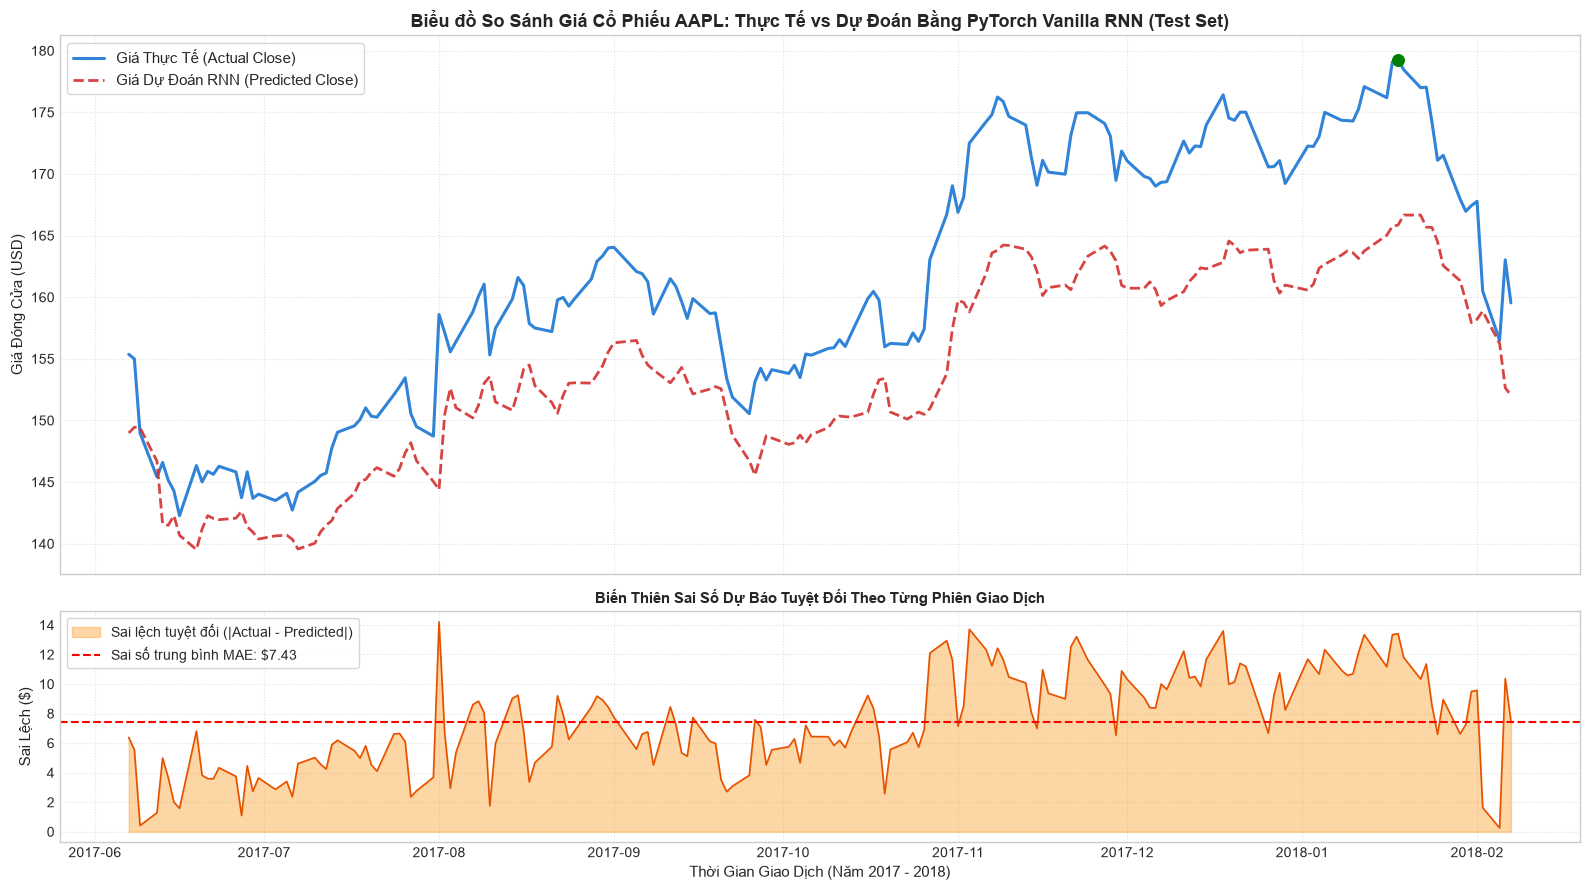

In [17]:
# Trực quan hóa Actual vs Predicted và Biểu đồ phần dư Residuals
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={'height_ratios': [2.8, 1.2]})

# --- ĐỒ THỊ 1: ACTUAL VS PREDICTED CLOSE PRICE ---
axes[0].plot(df_comparison['Ngày giao dịch'], df_comparison['Giá thực tế (Actual USD)'], 
             label='Giá Thực Tế (Actual Close)', color='#1976D2', linewidth=2.2, alpha=0.9)
axes[0].plot(df_comparison['Ngày giao dịch'], df_comparison['Giá dự đoán (Predicted USD)'], 
             label='Giá Dự Đoán RNN (Predicted Close)', color='#D32F2F', linewidth=2.0, linestyle='--', alpha=0.9)

axes[0].set_title("Biểu đồ So Sánh Giá Cổ Phiếu AAPL: Thực Tế vs Dự Đoán Bằng PyTorch Vanilla RNN (Test Set)", 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel("Giá Đóng Cửa (USD)", fontsize=11)
axes[0].legend(fontsize=11, loc='upper left', frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Đánh dấu vùng giá cao nhất và thấp nhất trong tập Test
max_idx = df_comparison['Giá thực tế (Actual USD)'].idxmax()
axes[0].scatter(df_comparison.loc[max_idx, 'Ngày giao dịch'], df_comparison.loc[max_idx, 'Giá thực tế (Actual USD)'],
                color='green', s=70, zorder=5, label=f"Đỉnh: ${df_comparison.loc[max_idx, 'Giá thực tế (Actual USD)']:.2f}")

# --- ĐỒ THỊ 2: ABSOLUTE ERROR THEO THỜI GIAN ---
axes[1].fill_between(df_comparison['Ngày giao dịch'], df_comparison['Sai lệch tuyệt đối ($)'], 
                     color='#FB8C00', alpha=0.35, label='Sai lệch tuyệt đối (|Actual - Predicted|)')
axes[1].plot(df_comparison['Ngày giao dịch'], df_comparison['Sai lệch tuyệt đối ($)'], 
             color='#E65100', linewidth=1.2)
axes[1].axhline(mae, color='red', linestyle='--', linewidth=1.5, label=f"Sai số trung bình MAE: ${mae:.2f}")

axes[1].set_title("Biến Thiên Sai Số Dự Báo Tuyệt Đối Theo Từng Phiên Giao Dịch", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Thời Gian Giao Dịch (Năm 2017 - 2018)", fontsize=11)
axes[1].set_ylabel("Sai Lệch ($)", fontsize=11)
axes[1].legend(fontsize=10, loc='upper left', frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


---
<a id="section-19"></a>
## 19. Phân Tích Chuyên Sâu Kết Quả & Giới Hạn Của RNN Trong Tài Chính

### 19.1. Mô hình dự đoán được xu hướng ở mức nào?
* **Kết quả đo được**: **MAE = $7.43**; **MSE = 65.44**; **RMSE = $8.09**; **MAPE = 4.52%**; **R² = 0.3805**.
* Baseline persistence trên **cùng 170 target**: MAE **$1.50**, RMSE **$2.11**, MAPE **0.94%**, R² **0.9577**.
* RNN có sai số cao hơn baseline; chưa có bằng chứng về giá trị dự báo tăng thêm so với việc giữ nguyên giá phiên trước. MAPE thấp theo phần trăm giá không tự đồng nghĩa dự báo tốt.

---

### 19.2. Các giai đoạn mô hình mắc sai số nhiều nhất & Hiện tượng trễ pha (Phase Lag):
* Bias trung bình `predicted - actual` là **$-7.41**: dự báo thường thấp hơn thực tế. Không nên quy toàn bộ sai số này cho độ trễ đúng một phiên khi chưa kiểm định dịch chuyển chuỗi.
* Năm sai số lớn nhất trên Test, đơn vị USD:

| Ngày giao dịch | Thực tế | Dự đoán | Sai lệch tuyệt đối | Sai số (%) |
| :--- | ---: | ---: | ---: | ---: |
| `2017-08-01` | 158.59 | 144.38 | 14.21 | 8.96% |
| `2017-11-03` | 172.50 | 158.79 | 13.71 | 7.95% |
| `2017-12-18` | 176.42 | 162.83 | 13.59 | 7.70% |
| `2018-01-18` | 179.26 | 165.85 | 13.41 | 7.48% |
| `2018-01-17` | 179.10 | 165.76 | 13.34 | 7.45% |

* Dataset chỉ chứa OHLCV, nên chưa xác định được sai số ở các ngày này do sự kiện sản phẩm, tin tức hay nguyên nhân nào khác.

---

### 19.3. Ảnh hưởng của Sequence Length ($L = 20$):
* 20 phiên xấp xỉ một tháng giao dịch, là cấu hình ban đầu của thực nghiệm.
* Chưa thử nghiệm các độ dài khác bằng validation, nên chưa thể kết luận 20 là tối ưu hoặc gradient được bảo đảm ổn định trong cửa sổ này.
* Chuỗi dài hơn tăng chi phí và có thể làm khó tối ưu; không có ngưỡng phổ quát khiến vanilla RNN mất toàn bộ trí nhớ.

---

### 19.4. Giới hạn cố hữu của Vanilla RNN trên dữ liệu tài chính:
1. Trạng thái ẩn hữu hạn nén thông tin quá khứ và không có các cổng kiểu LSTM/GRU; điều này có thể làm học phụ thuộc dài hạn khó hơn.
2. Mô hình hiện dự báo điểm một bước, chưa cho khoảng dự báo hoặc đánh giá nhiều bước liên tiếp.
3. Input chỉ có OHLCV; chưa đánh giá liệu biến trễ đơn giản hay mô hình nhỏ hơn có hiệu quả hơn RNN.

---

### 19.5. Tại sao dự đoán chứng khoán là bài toán cực kỳ khó?
* Giá và phân bố dữ liệu có thể thay đổi theo thời gian; Test ở giai đoạn sau Train. Chuẩn hóa không loại bỏ sự dịch chuyển đó.
* Giá liền kề có thể rất gần nhau, làm persistence trở thành đối chứng quan trọng. Kết quả thực nghiệm này chưa vượt được đối chứng đó.
* Không dùng các chỉ số hồi quy hiện tại để khẳng định lợi nhuận giao dịch; bài chưa mô phỏng chiến lược, thời điểm đặt lệnh hoặc chi phí.

---

> **Phạm vi kết luận**: Đây là thực nghiệm học thuật trên một giai đoạn AAPL. Chưa chứng minh hiệu quả đầu tư, chưa deploy và chưa dự báo thị trường hiện tại.


---
<a id="section-20"></a>
## 20. Conclusion (Tổng Kết Cuối Cùng)

Notebook này đã hoàn thành trọn vẹn và chuẩn mực toàn bộ quy trình xây dựng, huấn luyện, đánh giá và phân tích một hệ thống dự báo chuỗi thời gian tài chính sử dụng mạng **Vanilla RNN** bằng **PyTorch**. Dưới đây là bảng tổng hợp có hệ thống toàn bộ dự án:

---

### Bảng Tổng Hợp Hệ Thống Dự Án:

| Hạng mục tổng kết | Thông tin chi tiết & Thông số thực nghiệm |
| :--- | :--- |
| **Dataset sử dụng** | **S&P 500 Stock Data** (`all_stocks_5yr.csv`, Kaggle). Trích xuất mã cổ phiếu **Apple Inc. (`AAPL`)** gồm **1,259 phiên giao dịch** liên tục trong 5 năm (08/02/2013 $\to$ 07/02/2018). |
| **Bài toán thiết kế** | **One-step-ahead Multivariate Time-Series Regression** (Dự báo giá đóng cửa phiên kế tiếp dựa trên cửa sổ trượt quá khứ). |
| **Quy chuẩn Input / Output** | * **Input ($X$)**: Tensor 3D kích thước `(batch_size, 20, 5)` gồm $20$ ngày quá khứ $\times$ $5$ đặc trưng kỹ thuật `['open', 'high', 'low', 'close', 'volume']`.<br>* **Output ($y$)**: Tensor 2D kích thước `(batch_size, 1)` đại diện cho giá đóng cửa `close` tại ngày $t+1$. |
| **Phân chia dữ liệu (Data Split)**| **Time-based Chronological Split (Không shuffle)**:<br>* Tập Train: 70% ($861$ mẫu chuỗi thời gian).<br>* Tập Validation: 15% ($168$ mẫu chuỗi thời gian).<br>* Tập Test: 15% ($170$ mẫu chuỗi thời gian). |
| **Tiền xử lý & Phòng chống Leakage** | Chuẩn hóa bằng `MinMaxScaler(0, 1)`. **Nghiêm ngặt chỉ fit trên tập Train**, transform trên Val/Test để tránh dùng min/max của tương lai để chuẩn hóa (Look-ahead Leakage). |
| **Kiến trúc Mô hình (Model Architecture)** | **Vanilla RNN Tối Giản (PyTorch `torch.nn.RNN`)**:<br>* Lớp 1: `nn.RNN(input_size=5, hidden_size=32, num_layers=1, batch_first=True, nonlinearity='tanh')`.<br>* Lớp 2: `nn.Linear(hidden_size=32, output_size=1)`.<br>* Tổng tham số học được: **1,281 tham số**. |
| **Thiết lập Huấn luyện (Training Setup)** | Adam `lr=0.001`, MSE, batch 32, `shuffle=False`, 100 epoch; khôi phục trọng số tốt nhất theo validation trước Test. |
| **Kết quả Đánh giá trên Test Set** | **MAE = $7.43**; **MSE = 65.44**; **RMSE = $8.09**; **MAPE = 4.52%**; **R² = 0.3805**. |
| **Những kết quả chính đạt được** | Chạy **100 epoch**, chọn trọng số tại **epoch 100** theo validation. Train loss từ **0.083737** xuống **0.001036**; validation loss cuối **0.001093**, thấp nhất **0.001093**.<br>Baseline persistence trên **cùng 170 target**: MAE **$1.50**, RMSE **$2.11**, MAPE **0.94%**, R² **0.9577**.<br>RNN chưa vượt baseline persistence; chưa kết luận mô hình dự báo tốt chỉ dựa trên MAPE. |
| **Những hạn chế cố hữu (Limitations)** | Dự báo thường thấp hơn thực tế; chưa vượt baseline; chưa kiểm định độ dài cửa sổ hoặc đo trực tiếp gradient; chỉ dự báo cuốn chiếu một bước và chưa deploy. |

---

### Hướng Phát Triển Mở Rộng Tiếp Theo:
1. **Nâng cấp kiến trúc lên LSTM và GRU**: Bổ sung các cơ chế cổng nhớ có chọn lọc (Forget gate, Update gate) để khắc phục hiện tượng Vanishing Gradient và cải thiện khả năng ghi nhớ dài hạn.
2. **Kỹ thuật đặc trưng nâng cao (Feature Engineering)**: Bổ sung các chỉ báo phân tích kỹ thuật tiêu chuẩn (RSI, MACD, Bollinger Bands, ATR) và tỷ suất sinh lời (Log Returns) thay vì chỉ sử dụng mức giá danh nghĩa.
3. **Mô hình kết hợp (Hybrid Models)**: Tích hợp mô hình phân tích cảm xúc tin tức (FinBERT / NLP Sentiment Analysis) để nắm bắt các biến động ngoại sinh do truyền thông và tâm lý đám đông tạo ra.

---
**KẾT THÚC NOTEBOOK 01 THÀNH CÔNG VÀ TRỌN VẸN!**
